In [1]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
# Walks up from the notebook's working directory until it finds pyproject.toml,
# then adds that directory to sys.path so `from twopoint_lockin import ...` etc. work
# regardless of which subfolder the notebook lives in. PROJECT_ROOT is also exposed
# so cells below can build absolute paths to data/ and the vendored qickdawg package.
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
# Also add notebook_modules/ so `from twopoint_lockin import ...` etc. work
# without per-notebook sys.path tweaks. The five .py modules used by these
# notebooks live there now (lockin_extensions, multipoint_lockin_program,
# nv_magnetometry_analysis, odmr_sensitivity, twopoint_lockin).
_nb_modules_dir = PROJECT_ROOT / "notebook_modules"
if _nb_modules_dir.exists() and str(_nb_modules_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_modules_dir))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project


# Basic NV Center Testing

Simple tests for NV center setup using QICK-DAWG on the RFSoC4x2.

- **Section 0** – Setup & connection  
- **Section 1** – Default configuration (set `adc_channel` to 0 or 1 for your photodiode)  
- **Section 2** – PL readout (check ADC signal); optional **CSV export** for channels D & C  
- **Section 3** – ODMR spectrum  
- **Section 4** – Magnetic field sensitivity  
- **Section 5** – Readout window calibration  
- **Section 6** – Two-point lock-in modulation (preliminary test)  

Turn the laser ON and connect the photodiode to the ADC before running.

---
## Section 0: Setup & Connection

In [2]:
%load_ext autoreload
%matplotlib inline
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit

In [3]:
# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '192.168.0.103'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

Connected to RFSoC at 192.168.0.103


---
## Section 1: Default Configuration

Set `adc_channel` to **0** or **1** (whichever ADC your photodiode is connected to). You can also use `"D"` for 0 or `"C"` for 1. Run the diagnostic in the next cell if you are not sure which channel has signal.

**Diagnostic:** Run the cell below to read both ADC channels. Use the channel with the larger signal; set `adc_channel` in the config cell to that number (0 or 1) and re-run the config cell.

In [4]:
default_config = qd.NVConfiguration()

# ADC channel: 0 or 1 (run diagnostic above if unsure which has your photodiode)
# 0 for ADC_D and 1 for ADC_C
default_config.adc_channel = 0
default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 500
default_config.readout_integration_tus = 213  # max ~106.7 µs; auto-sets _treg and _tns

print("Default configuration:")
print(f"  ADC channel:     {default_config.adc_channel}")
print(f"  MW channel:      {default_config.mw_channel}")
print(f"  MW gain:         {default_config.mw_gain}")
print(f"  Relax delay:     {default_config.relax_delay_tns:.0f} ns")
print(f"  Readout int.:    {default_config.readout_integration_tus:.2f} µs  ({default_config.readout_integration_treg} treg)")

# --- Data directory routing (added during reorg 2026-05-06) ---
from pathlib import Path as _Path
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIRS = {
    "odmr":            DATA_DIR / "odmr_sweeps",
    "twopoint":        DATA_DIR / "lockin_twopoint",
    "multipoint":      DATA_DIR / "lockin_multipoint",
    "pl_dual_channel": DATA_DIR / "pl_dual_channel",
    "calibration":     DATA_DIR / "calibration",
}
for _d in DATA_DIRS.values():
    _d.mkdir(parents=True, exist_ok=True)
def data_path(category, filename):
    """Resolve a data filename to its category subfolder under data/."""
    return DATA_DIRS[category] / filename
print(f"  Data root:       {DATA_DIR}  (subfolders: {sorted(DATA_DIRS)})")



Default configuration:
  ADC channel:     0
  MW channel:      1
  MW gain:         5000
  Relax delay:     501 ns
  Readout int.:    213.00 µs  (65434 treg)
  Data root:       /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data  (subfolders: ['calibration', 'multipoint', 'odmr', 'pl_dual_channel', 'twopoint'])


---
## Section 2: PL Readout

Single PL intensity readout. If you see 0.00, run the diagnostic in Section 1 and set `adc_channel` to the channel that shows signal, then re-run the config and this cell.

In [4]:
from qickdawg.nvpulsing.nv_live_helpers import run_fast_pl_no_display, run_live_odmr

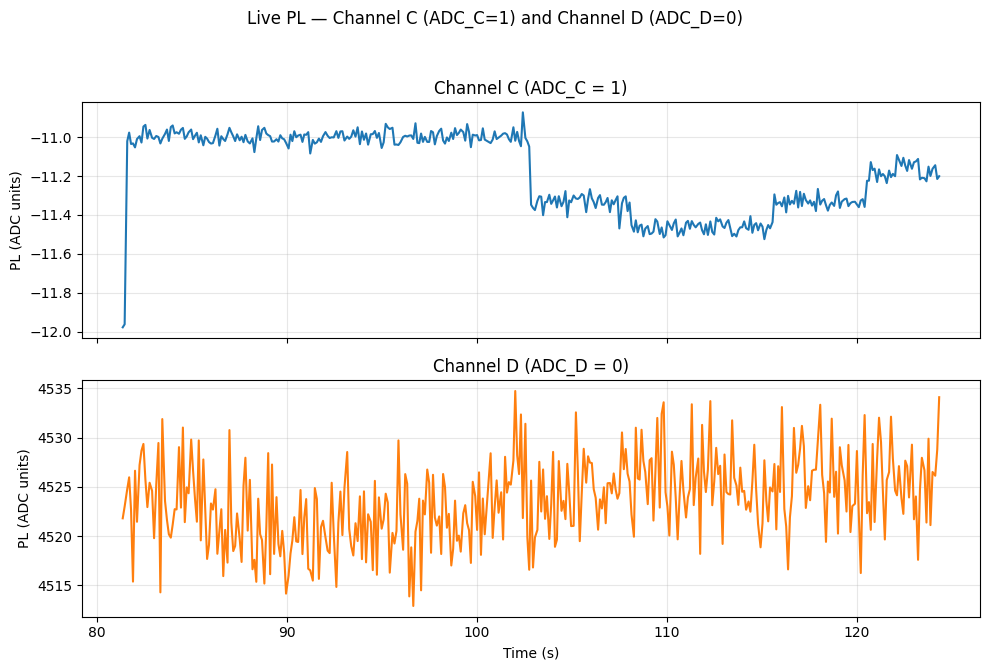

Live PL stopped.


In [41]:
# Live PL — original single-point acquisition.
# Each call to PLIntensity.acquire() returns one averaged value per channel (reps=cfg.reps).
# ~165 ms per displayed point. Stop with Interrupt (■).

from collections import deque
from time import perf_counter
from IPython.display import display as _ipy_display

cfg_c = copy(default_config); cfg_c.adc_channel = 1  # ADC_C
cfg_d = copy(default_config); cfg_d.adc_channel = 0  # ADC_D
prog_c = qd.PLIntensity(cfg_c)
prog_d = qd.PLIntensity(cfg_d)

n_pts = 400
t_c, d_c = deque(maxlen=n_pts), deque(maxlen=n_pts)
t_d, d_d = deque(maxlen=n_pts), deque(maxlen=n_pts)

plt.ion()
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Live PL — Channel C (ADC_C=1) and Channel D (ADC_D=0)')
line_c, = axes[0].plot([], [], 'C0')
line_d, = axes[1].plot([], [], 'C1')
for ax in axes:
    ax.set_ylabel('PL (ADC units)'); ax.grid(True, alpha=0.3)
axes[1].set_xlabel('Time (s)')
handle = _ipy_display(fig, display_id=True)

t0 = perf_counter()
try:
    while True:
        t = perf_counter() - t0
        val_c = prog_c.acquire()  # PLIntensity.acquire() — averages reps, returns one float
        val_d = prog_d.acquire()
        t_c.append(t); d_c.append(val_c)
        t_d.append(t); d_d.append(val_d)
        line_c.set_data(list(t_c), list(d_c))
        line_d.set_data(list(t_d), list(d_d))
        axes[0].set_title('Channel C (ADC_C = 1)'); axes[0].relim(); axes[0].autoscale_view()
        axes[1].set_title('Channel D (ADC_D = 0)'); axes[1].relim(); axes[1].autoscale_view()
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        fig.canvas.draw_idle()
        handle.update(fig)
except KeyboardInterrupt:
    print('Live PL stopped.')
finally:
    plt.ioff(); plt.close(fig)


### Fast PL Readout

In [11]:
# PL acquisition — hardware-rate, no display overhead.
# Runs for duration_sec seconds, then saves to CSV.
# Stop early with Interrupt (■).

fast_pl_filename = "fast_PL_dual_channel.csv"
df_fast_pl = run_fast_pl_no_display(
    default_config,
    duration_sec=120,   # 2 minutes; set None to run until interrupted
    batch_size=5000,
    csv_filename=fast_pl_filename,
)
n = len(df_fast_pl)
t_total = float(df_fast_pl["time_s"].iloc[-1]) if n else 0
print(f"Collected {n} points in {t_total:.2f} s  →  {n/t_total:.0f} pts/s" if t_total > 0 else f"{n} points")


Fast PL stopped — 10000 points collected.
Saved 10000 points to fast_PL_dual_channel.csv
Collected 10000 points in 1.12 s  →  8929 pts/s


---
## Section 3: ODMR Spectrum

In [5]:
# =============================================================================
# ODMR sweep — edit ALL parameters below, then run this cell once.
# Builds config, runs LockinODMR, saves full sweep to CSV (MW on / MW off / contrast).
# =============================================================================
import pandas as pd
from pathlib import Path
from datetime import datetime
import importlib

from IPython.display import FileLink, display

# --- Microwave & timing ---
ODMR_MW_GAIN = 10500              # 0–32767; ↑ if contrast weak, ↓ if saturated
ODMR_PRE_INIT = True             # MW+laser prepulse before sweep
ODMR_REPS = 10                   # averages per frequency point
ODMR_RELAX_DELAY_TREG = 500000      # delay register units between MW on/off segments 100000 

# --- ADC readout integration (photodiode PL averaging time) ---
ODMR_READOUT_INTEGRATION_TUS = 213   # or set e.g. 50.0 (microseconds)

# --- Frequency sweep (MHz) ---
MW_FREQ_START_MHZ = 2600
MW_FREQ_STOP_MHZ = 3100
MW_FREQ_STEP_MHZ = 1             # step size (MHz); narrow range once peaks are known
# Instead of delta, you can use a fixed point count, e.g.:
#   config_odmr.add_linear_sweep("mw", "fMHz", start=2700, stop=3000, nsweep_points=301)
# (then comment out the add_linear_sweep call in the build block below and paste there)

# --- CSV export ---
SAVE_ODMR_CSV = True             # set False to only acquire (still defines d, prog_odmr for plots)

# --- If reference should be flat but shows dips: try True (explicit low-gain pulse in ref. window) ---
ODMR_REFERENCE_ZERO_GAIN_PULSE = False
ODMR_REFERENCE_PULSE_GAIN = 1       # use 1 if gain 0 faults; increase only if needed
# --- Only if reference is flat and signal is not (mis-labeled shots), try True ---
ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE = False

# --- Build configuration (inherits adc_channel, mw_channel, laser from default_config) ---
config_odmr = copy(default_config)
config_odmr.odmr_reference_zero_gain_pulse = ODMR_REFERENCE_ZERO_GAIN_PULSE
config_odmr.odmr_reference_pulse_gain = ODMR_REFERENCE_PULSE_GAIN
config_odmr.odmr_lockin_swap_signal_reference = ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE
config_odmr.readout_integration_tus = ODMR_READOUT_INTEGRATION_TUS
config_odmr.mw_gain = ODMR_MW_GAIN
config_odmr.pre_init = ODMR_PRE_INIT
config_odmr.reps = ODMR_REPS
config_odmr.relax_delay_treg = ODMR_RELAX_DELAY_TREG
config_odmr.add_linear_sweep(
    "mw", "fMHz",
    start=MW_FREQ_START_MHZ,
    stop=MW_FREQ_STOP_MHZ,
    delta=MW_FREQ_STEP_MHZ,
)

print("ODMR configuration:")
print(f"  ADC channel: {config_odmr.adc_channel}  MW channel: {config_odmr.mw_channel}  gain: {config_odmr.mw_gain}")
print(f"  Sweep: {config_odmr.mw_start_fMHz:.3f} → {config_odmr.mw_end_fMHz:.3f} MHz  ({config_odmr.nsweep_points} pts)")
print(f"  reps: {config_odmr.reps}  est. time: {qd.LockinODMR(config_odmr).total_time():.1f} s")

prog_odmr = qd.LockinODMR(config_odmr)
d = prog_odmr.acquire(progress=True)
print("Acquisition done.")

if SAVE_ODMR_CSV:
    odmr_df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = data_path("odmr", f"odmr_sweep_{ts}.csv")
    odmr_df.to_csv(csv_path, index=False)
    LAST_ODMR_CSV = csv_path
    LAST_ODMR_DF = odmr_df.copy()
    print(f"CSV: {len(odmr_df)} rows → {csv_path.resolve()}")
    display(FileLink(csv_path.name))


Requested 2600 to 3100 by 1
Instead using 2600.00000038147 to 3099.9998096466065 by 0.9999996185302735 in 501 steps
ODMR configuration:
  ADC channel: 0  MW channel: 1  gain: 10500
  Sweep: 2600.000 → 3100.000 MHz  (501 pts)
  reps: 10  est. time: 18.4 s


  0%|          | 0/5010 [00:00<?, ?it/s]

Acquisition done.
CSV: 501 rows → /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260507_162220.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/notebooks/01_basic_nv_testing/odmr_sweep_20260507_162220.csv

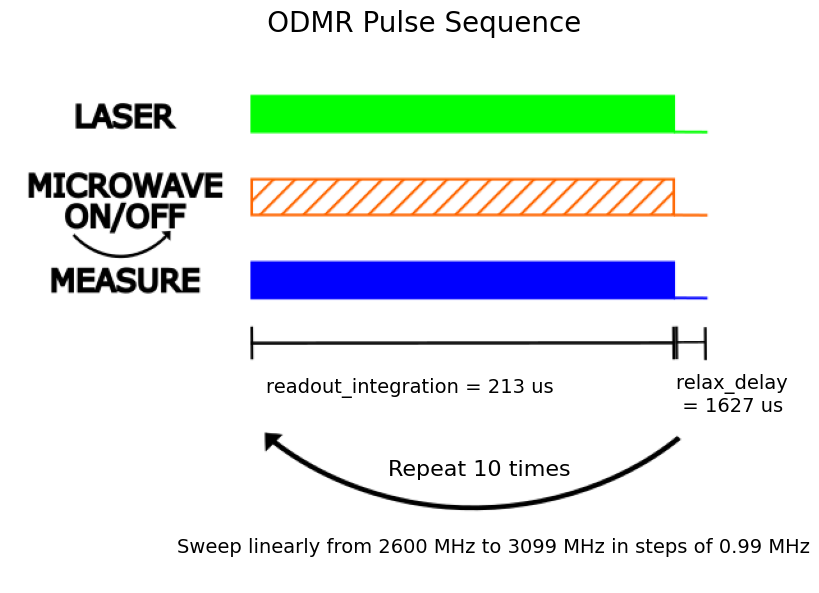

In [6]:
qd.LockinODMR.plot_sequence(config_odmr)

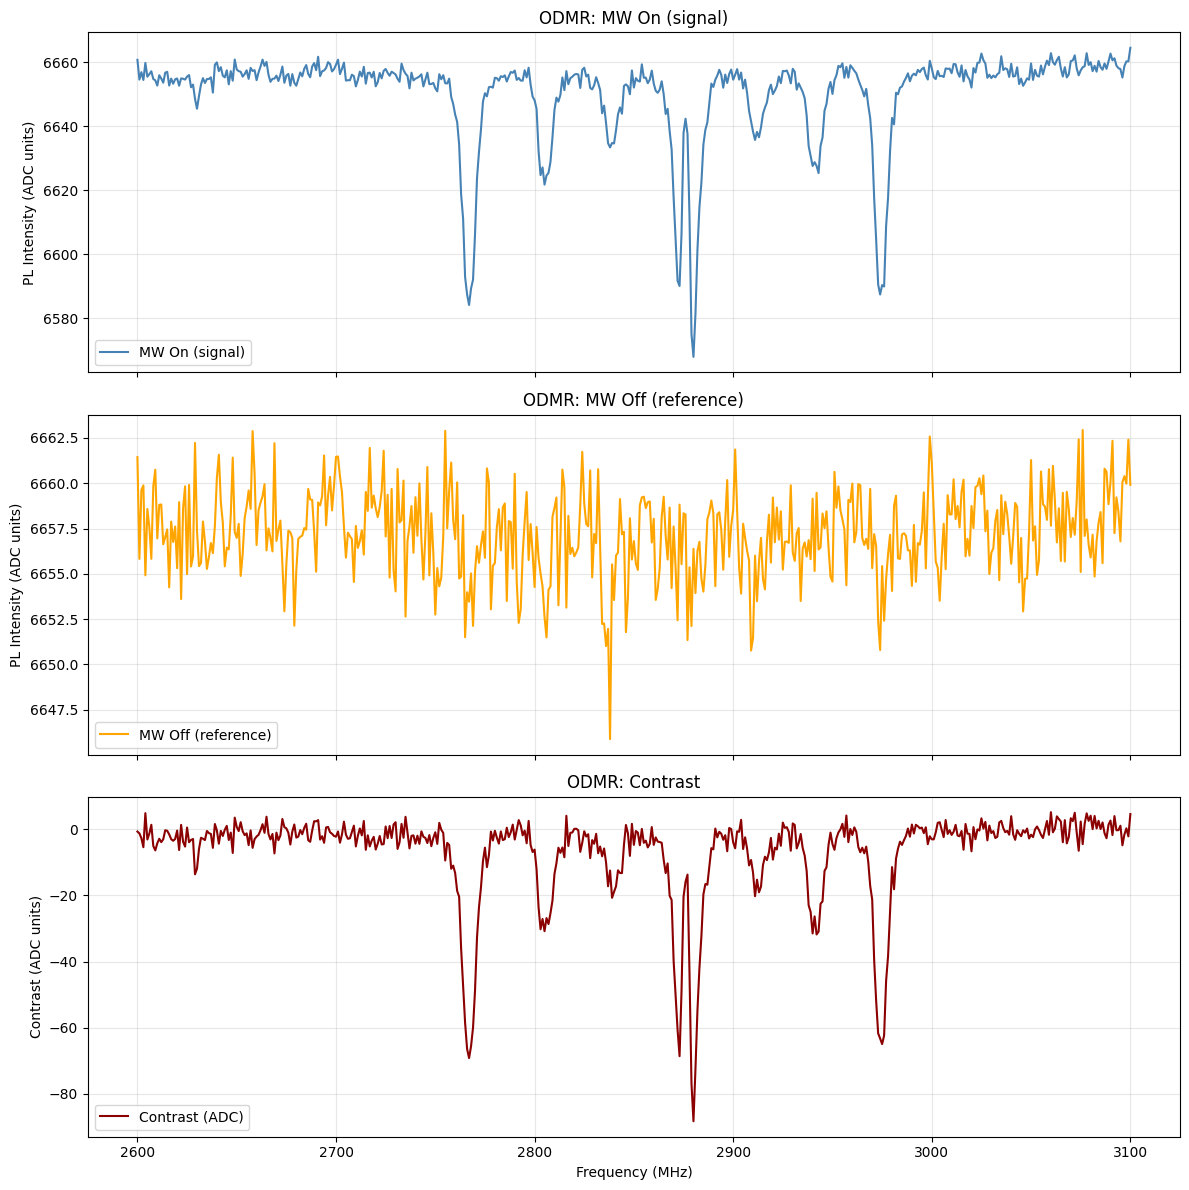

In [7]:
# Plot ODMR spectrum with subplots for MW On, MW Off, and Contrast
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot MW On (signal)
axes[0].plot(d.frequencies, d.signal, label='MW On (signal)', color='steelblue')
axes[0].set_ylabel('PL Intensity (ADC units)')
axes[0].set_title('ODMR: MW On (signal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MW Off (reference)
axes[1].plot(d.frequencies, d.reference, label='MW Off (reference)', color='orange')
axes[1].set_ylabel('PL Intensity (ADC units)')
axes[1].set_title('ODMR: MW Off (reference)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot Contrast
axes[2].plot(d.frequencies, d.contrast, label='Contrast (ADC)', color='darkred')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('Contrast (ADC units)')
axes[2].set_title('ODMR: Contrast')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

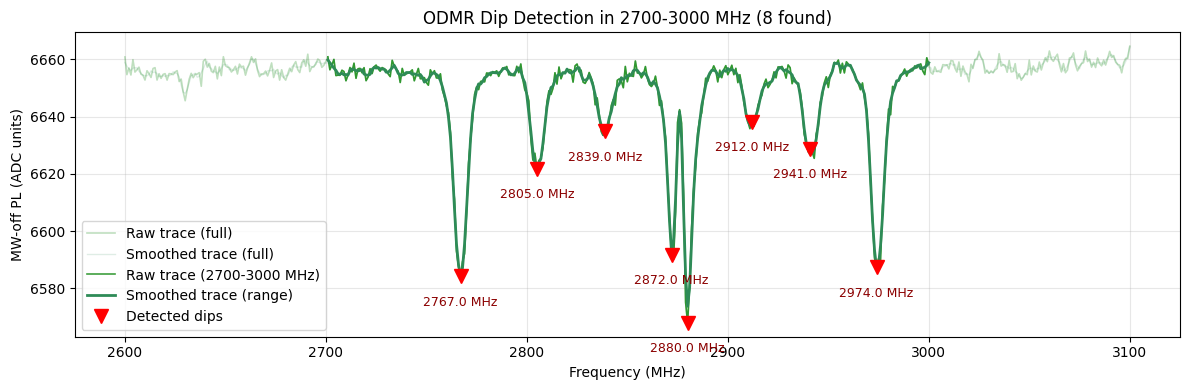

Trace source: Current acquisition (`d.reference`)
Analyzed range: 2700 to 3000 MHz
Using column 1 as x and column 3 as y when a CSV path is provided.
Prominence threshold used: 6.83 ADC
Detected ODMR dips in selected range:
  Dip 1: 2767.00 MHz  (6584.1954 ADC)
  Dip 2: 2805.00 MHz  (6621.8186 ADC)
  Dip 3: 2839.00 MHz  (6634.8201 ADC)
  Dip 4: 2872.00 MHz  (6591.7268 ADC)
  Dip 5: 2880.00 MHz  (6567.9702 ADC)
  Dip 6: 2912.00 MHz  (6638.2791 ADC)
  Dip 7: 2941.00 MHz  (6628.8222 ADC)
  Dip 8: 2974.00 MHz  (6587.4582 ADC)
Suggested resonance frequency (deepest dip in range): 2880.00 MHz


In [12]:
# Detect and mark ODMR dips from frequency (column 1) vs MW-off PL (column 3)
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks as scipy_find_peaks, savgol_filter

ODMR_CSV_PATH = None
# ODMR_CSV_PATH = Path("odmr_sweep_20260320_132708.csv")
# Set ODMR_CSV_PATH to a saved CSV to analyze first-column frequency vs third-column PL.
# Leave it as None to analyze the current in-memory sweep (`d.reference`).


def load_odmr_trace(csv_path=None):
    if csv_path is None:
        return (
            np.asarray(d.frequencies, dtype=float),
            np.asarray(d.signal, dtype=float),
            'MW-off reference',
            'Current acquisition (`d.reference`)'
        )

    odmr_df = pd.read_csv(Path(csv_path))
    if {'frequency_MHz', 'photoluminescence_mw_off_ADC'}.issubset(odmr_df.columns):
        x = odmr_df['frequency_MHz'].to_numpy(dtype=float)
        y = odmr_df['photoluminescence_mw_off_ADC'].to_numpy(dtype=float)
        y_label = 'photoluminescence_mw_off_ADC'
    else:
        x = odmr_df.iloc[:, 0].to_numpy(dtype=float)
        y = odmr_df.iloc[:, 2].to_numpy(dtype=float)
        y_label = odmr_df.columns[2]

    return x, y, y_label, str(Path(csv_path).resolve())


def find_odmr_dips(
    frequencies,
    signal,
    n_dips=4,
    prominence_factor=0.4,
    min_prominence=6.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=None,
    freq_max=None,
):
    """Find ODMR transmission dips (local minima) in the selected PL trace within a frequency range."""
    x = np.asarray(frequencies, dtype=float)
    y = np.asarray(signal, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # Limit analysis to within freq_min and freq_max if given
    if freq_min is not None or freq_max is not None:
        idx_range = np.ones_like(x, dtype=bool)
        if freq_min is not None:
            idx_range &= x >= freq_min
        if freq_max is not None:
            idx_range &= x <= freq_max
        x = x[idx_range]
        y = y[idx_range]

    if len(x) < 5:
        raise ValueError('Need at least 5 finite points to detect ODMR dips.')

    w = int(max(5, smooth_window))
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        w = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if w < polyorder + 2:
        y_smooth = y.copy()
    else:
        y_smooth = savgol_filter(y, window_length=w, polyorder=min(polyorder, w - 2), mode='interp')

    trend = np.polyval(np.polyfit(x, y_smooth, 1), x)
    y_detr = y_smooth - trend

    prominence = max(float(min_prominence), np.std(y_detr) * float(prominence_factor))
    dip_idx, props = scipy_find_peaks(
        -y_detr,
        prominence=prominence,
        distance=max(1, int(min_distance_pts)),
    )

    if len(dip_idx) == 0:
        return dip_idx, y_smooth, y_detr, props, prominence, x, y

    prom_arr = props.get('prominences', np.zeros(len(dip_idx), dtype=float))
    keep = np.argsort(prom_arr)[-int(n_dips):]
    dip_idx = dip_idx[keep]
    dip_idx = dip_idx[np.argsort(x[dip_idx])]
    return dip_idx, y_smooth, y_detr, props, prominence, x, y


# Restrict frequency range for dip detection: 2700 to 3000 MHz
FREQ_MIN = 2700
FREQ_MAX = 3000

frequencies, trace, trace_label, trace_source = load_odmr_trace(ODMR_CSV_PATH)
dip_idx, trace_smooth, trace_detr, dip_props, used_prominence, x_range, y_range = find_odmr_dips(
    frequencies,
    trace,
    n_dips=8,
    prominence_factor=0.4,
    min_prominence=4.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=FREQ_MIN,
    freq_max=FREQ_MAX,
)

plt.figure(figsize=(12, 4))

# Plot full raw and smoothed traces for visual context
plt.plot(frequencies, trace, color='green', linewidth=1.2, alpha=0.25, label='Raw trace (full)')
plt.plot(frequencies, savgol_filter(trace, window_length=7 if len(trace) > 7 else 5, polyorder=2 if len(trace) > 2 else 1, mode='interp'), color='seagreen', linewidth=1.0, alpha=0.15, label='Smoothed trace (full)')

# Plot zoomed-in range (2700-3000)
plt.plot(x_range, y_range, color='green', linewidth=1.2, alpha=0.75, label=f'Raw trace ({FREQ_MIN}-{FREQ_MAX} MHz)')
plt.plot(x_range, trace_smooth, color='seagreen', linewidth=2.0, label='Smoothed trace (range)')

if len(dip_idx) > 0:
    plt.plot(x_range[dip_idx], y_range[dip_idx], 'rv', markersize=10, label='Detected dips')
    for i, idx in enumerate(dip_idx):
        plt.annotate(
            f"{x_range[idx]:.1f} MHz",
            xy=(x_range[idx], y_range[idx]),
            xytext=(0, -14),
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=9,
            color='darkred',
        )

plt.ylabel('MW-off PL (ADC units)' if trace_label == 'MW-off reference' else trace_label)
plt.xlabel('Frequency (MHz)')
plt.title(f'ODMR Dip Detection in {FREQ_MIN}-{FREQ_MAX} MHz ({len(dip_idx)} found)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Trace source: {trace_source}')
print(f'Analyzed range: {FREQ_MIN} to {FREQ_MAX} MHz')
print('Using column 1 as x and column 3 as y when a CSV path is provided.')
print(f'Prominence threshold used: {used_prominence:.2f} ADC')

if len(dip_idx) == 0:
    print('No ODMR dips found in the specified range. Lower `min_prominence` or reduce `smooth_window`.')
else:
    print('Detected ODMR dips in selected range:')
    for i, idx in enumerate(dip_idx):
        print(f"  Dip {i+1}: {x_range[idx]:.2f} MHz  ({y_range[idx]:.4f} ADC)")

    deepest_idx = dip_idx[np.argmin(y_range[dip_idx])]
    print(f'Suggested resonance frequency (deepest dip in range): {x_range[deepest_idx]:.2f} MHz')


### Live ODMR — MW **on** (PL)


In [11]:
# Live ODMR — MW ON photoluminescence vs frequency (not contrast)
# Requires: run the ODMR configuration & acquire cell first so `prog_odmr` exists.
# Each refresh is a full sweep. For faster updates, narrow the sweep or lower ODMR_REPS.
# Press Stop (■) to interrupt the kernel and exit.


import run_live_odmr

run_live_odmr(
    prog_odmr,
    os_mhz=120,
    xlim=(None, 3100),
)


ModuleNotFoundError: No module named 'run_live_odmr'

## Three Groups Live

In [ ]:
# Live ODMR — MW ON photoluminescence vs frequency (not contrast)
# Requires: run the ODMR configuration & acquire cell first so `prog_odmr` exists.
# Each refresh is a full sweep. For faster updates, narrow the sweep or lower ODMR_REPS.
# Press Stop (■) to interrupt the kernel and exit.

run_live_odmr(
    prog_odmr,
    os_mhz=0,
    xlim=(None, 2850),
)


---
## Section 4: Sensitivity Measurement

In [64]:
from odmr_sensitivity import quick_sensitivity
quick_sensitivity(d)

Sensitivity (reference): 45.20 uT/sqrt(Hz)
trace=reference, center=2874.19 MHz, FWHM=226.07 MHz
Sensitivity (signal): 48.41 uT/sqrt(Hz)
trace=signal, center=2870.24 MHz, FWHM=213.89 MHz


{'reference': {'trace': 'reference',
  'center_ghz': 2.874194120787365,
  'center_mhz': 2874.194120787365,
  'gamma_ghz': 0.11303631649605818,
  'fwhm_mhz': 226.07263299211635,
  'noise_std': 9.604523187732964,
  'noise_density': 0.14017340113719198,
  'max_slope_per_ghz': 110.74957655809948,
  'point_time_s': 0.000213,
  'sensitivity_t_rt_hz': 4.520281750360099e-05,
  'sensitivity_text': '45.20 uT/sqrt(Hz)',
  'noise_window_ghz': (2.7, 2.8)},
 'signal': {'trace': 'signal',
  'center_ghz': 2.8702406925837582,
  'center_mhz': 2870.240692583758,
  'gamma_ghz': 0.10694411247544294,
  'fwhm_mhz': 213.8882249508859,
  'noise_std': 10.931645208413942,
  'noise_density': 0.15954210937254845,
  'max_slope_per_ghz': 117.69479524161967,
  'point_time_s': 0.000213,
  'sensitivity_t_rt_hz': 4.841278211065779e-05,
  'sensitivity_text': '48.41 uT/sqrt(Hz)',
  'noise_window_ghz': (2.7, 2.8)}}

## Section 5: Test Narrow Sweep

In [ ]:
# =============================================================================
# ODMR sweep — edit ALL parameters below, then run this cell once.
# Builds config, runs LockinODMR, saves full sweep to CSV (MW on / MW off / contrast).
# =============================================================================
import pandas as pd
from pathlib import Path
from datetime import datetime
from IPython.display import FileLink, display

# --- Microwave & timing ---
ODMR_MW_GAIN = 10500              # 0–32767; ↑ if contrast weak, ↓ if saturated
ODMR_PRE_INIT = True             # MW+laser prepulse before sweep
ODMR_REPS = 10                   # averages per frequency point
ODMR_RELAX_DELAY_TREG = 500     # delay register units between MW on/off segments

# --- ADC readout integration (photodiode PL averaging time) ---
ODMR_READOUT_INTEGRATION_TUS = qd.max_int_time_tus   # or set e.g. 50.0 (microseconds)

# --- Frequency sweep (MHz) ---
# Change ODMR_TARGET_PEAK_MHZ to inspect another feature.
# CSV-derived lower feature: requested ~2810 MHz region -> fitted center ~= 2797.53 MHz.
ODMR_TARGET_PEAK_MHZ = 2797.53
ODMR_NARROW_HALF_RANGE_MHZ = 20.0
MW_FREQ_START_MHZ = ODMR_TARGET_PEAK_MHZ - ODMR_NARROW_HALF_RANGE_MHZ
MW_FREQ_STOP_MHZ = ODMR_TARGET_PEAK_MHZ + ODMR_NARROW_HALF_RANGE_MHZ
MW_FREQ_STEP_MHZ = 0.5           # step size (MHz); reduce for a cleaner peak fit
# Instead of delta, you can use a fixed point count, e.g.:
#   config_odmr.add_linear_sweep("mw", "fMHz", start=2700, stop=3000, nsweep_points=301)
# (then comment out the add_linear_sweep call in the build block below and paste there)

# --- CSV export ---
SAVE_ODMR_CSV = True             # set False to only acquire (still defines d, prog_odmr for plots)

# --- If reference should be flat but shows dips: try True (explicit low-gain pulse in ref. window) ---
ODMR_REFERENCE_ZERO_GAIN_PULSE = False
ODMR_REFERENCE_PULSE_GAIN = 1       # use 1 if gain 0 faults; increase only if needed
# --- Only if reference is flat and signal is not (mis-labeled shots), try True ---
ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE = False

# --- Build configuration (inherits adc_channel, mw_channel, laser from default_config) ---
config_odmr = copy(default_config)
config_odmr.odmr_reference_zero_gain_pulse = ODMR_REFERENCE_ZERO_GAIN_PULSE
config_odmr.odmr_reference_pulse_gain = ODMR_REFERENCE_PULSE_GAIN
config_odmr.odmr_lockin_swap_signal_reference = ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE
config_odmr.readout_integration_tus = ODMR_READOUT_INTEGRATION_TUS
config_odmr.mw_gain = ODMR_MW_GAIN
config_odmr.pre_init = ODMR_PRE_INIT
config_odmr.reps = ODMR_REPS
config_odmr.relax_delay_treg = ODMR_RELAX_DELAY_TREG
config_odmr.add_linear_sweep(
    "mw", "fMHz",
    start=MW_FREQ_START_MHZ,
    stop=MW_FREQ_STOP_MHZ,
    delta=MW_FREQ_STEP_MHZ,
)

print("ODMR configuration:")
print(f"  ADC channel: {config_odmr.adc_channel}  MW channel: {config_odmr.mw_channel}  gain: {config_odmr.mw_gain}")
print(f"  Target peak: {ODMR_TARGET_PEAK_MHZ:.3f} MHz  +/- {ODMR_NARROW_HALF_RANGE_MHZ:.1f} MHz")
print(f"  Sweep: {config_odmr.mw_start_fMHz:.3f} → {config_odmr.mw_end_fMHz:.3f} MHz  ({config_odmr.nsweep_points} pts)")
print(f"  reps: {config_odmr.reps}  est. time: {qd.LockinODMR(config_odmr).total_time():.1f} s")

prog_odmr = qd.LockinODMR(config_odmr)
d = prog_odmr.acquire(progress=True)
print("Acquisition done.")

if SAVE_ODMR_CSV:
    odmr_df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = data_path("odmr", f"odmr_sweep_{ts}.csv")
    odmr_df.to_csv(csv_path, index=False)
    LAST_ODMR_CSV = csv_path
    LAST_ODMR_DF = odmr_df.copy()
    print(f"CSV: {len(odmr_df)} rows → {csv_path.resolve()}")
    display(FileLink(csv_path.name))

qd.LockinODMR.plot_sequence(config_odmr)

#------------------------------------------------------------------------

# Plot ODMR spectrum (Signal and Reference only)
fig, ax = plt.subplots(figsize=(12, 7), sharex=True)

ax.plot(d.frequencies, d.signal,    label='MW On (signal)',    color='steelblue')
ax.set_ylabel('PL Intensity (ADC units)')
ax.set_title('ODMR: Signal and Reference')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#------------------------------------------------------------------------


# Detect and mark ODMR dips from frequency (column 1) vs MW-off PL (column 3)
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks as scipy_find_peaks, savgol_filter

ODMR_CSV_PATH = None
# ODMR_CSV_PATH = Path("odmr_sweep_20260320_132708.csv")
# Set ODMR_CSV_PATH to a saved CSV to analyze first-column frequency vs third-column PL.
# Leave it as None to analyze the current in-memory sweep (`d.reference`).


def load_odmr_trace(csv_path=None):
    if csv_path is None:
        return (
            np.asarray(d.frequencies, dtype=float),
            np.asarray(d.reference, dtype=float),
            'MW-off reference',
            'Current acquisition (`d.reference`)'
        )

    odmr_df = pd.read_csv(Path(csv_path))
    if {'frequency_MHz', 'photoluminescence_mw_off_ADC'}.issubset(odmr_df.columns):
        x = odmr_df['frequency_MHz'].to_numpy(dtype=float)
        y = odmr_df['photoluminescence_mw_off_ADC'].to_numpy(dtype=float)
        y_label = 'photoluminescence_mw_off_ADC'
    else:
        x = odmr_df.iloc[:, 0].to_numpy(dtype=float)
        y = odmr_df.iloc[:, 2].to_numpy(dtype=float)
        y_label = odmr_df.columns[2]

    return x, y, y_label, str(Path(csv_path).resolve())


def find_odmr_dips(
    frequencies,
    signal,
    n_dips=4,
    prominence_factor=0.4,
    min_prominence=8.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
):
    """Find ODMR transmission dips (local minima) in the selected PL trace."""
    x = np.asarray(frequencies, dtype=float)
    y = np.asarray(signal, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if len(x) < 5:
        raise ValueError('Need at least 5 finite points to detect ODMR dips.')

    w = int(max(5, smooth_window))
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        w = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if w < polyorder + 2:
        y_smooth = y.copy()
    else:
        y_smooth = savgol_filter(y, window_length=w, polyorder=min(polyorder, w - 2), mode='interp')

    trend = np.polyval(np.polyfit(x, y_smooth, 1), x)
    y_detr = y_smooth - trend

    prominence = max(float(min_prominence), np.std(y_detr) * float(prominence_factor))
    dip_idx, props = scipy_find_peaks(
        -y_detr,
        prominence=prominence,
        distance=max(1, int(min_distance_pts)),
    )

    if len(dip_idx) == 0:
        return dip_idx, y_smooth, y_detr, props, prominence

    prom_arr = props.get('prominences', np.zeros(len(dip_idx), dtype=float))
    keep = np.argsort(prom_arr)[-int(n_dips):]
    dip_idx = dip_idx[keep]
    dip_idx = dip_idx[np.argsort(x[dip_idx])]
    return dip_idx, y_smooth, y_detr, props, prominence


frequencies, trace, trace_label, trace_source = load_odmr_trace(ODMR_CSV_PATH)
dip_idx, trace_smooth, trace_detr, dip_props, used_prominence = find_odmr_dips(
    frequencies,
    trace,
    n_dips=4,
    prominence_factor=0.4,
    min_prominence=8.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, trace, color='green', linewidth=1.2, alpha=0.45, label='Raw trace')
plt.plot(frequencies, trace_smooth, color='seagreen', linewidth=2.0, label='Smoothed trace')

if len(dip_idx) > 0:
    plt.plot(frequencies[dip_idx], trace[dip_idx], 'rv', markersize=10, label='Detected dips')
    for i, idx in enumerate(dip_idx):
        plt.annotate(
            f"{frequencies[idx]:.1f} MHz",
            xy=(frequencies[idx], trace[idx]),
            xytext=(0, -14),
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=9,
            color='darkred',
        )

plt.ylabel('MW-off PL (ADC units)' if trace_label == 'MW-off reference' else trace_label)
plt.xlabel('Frequency (MHz)')
plt.title(f'ODMR Dip Detection ({len(dip_idx)} found)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Trace source: {trace_source}')
print('Using column 1 as x and column 3 as y when a CSV path is provided.')
print(f'Prominence threshold used: {used_prominence:.2f} ADC')

if len(dip_idx) == 0:
    print('No ODMR dips found. Lower `min_prominence` or reduce `smooth_window`.')
else:
    print('Detected ODMR dips:')
    for i, idx in enumerate(dip_idx):
        print(f"  Dip {i+1}: {frequencies[idx]:.2f} MHz  ({trace[idx]:.4f} ADC)")

    deepest_idx = dip_idx[np.argmin(trace[dip_idx])]
    print(f'Suggested resonance frequency: {frequencies[deepest_idx]:.2f} MHz')


#------------------------------------------------------------------------

from odmr_sensitivity import quick_sensitivity
quick_sensitivity(d)

### Live ODMR — MW **on** (PL), not contrast

The cell above plots **contrast (%)** vs frequency. Use this cell to watch **photoluminescence with microwaves on** (`signal` from `LockinODMR`, in ADC units after normalization) while you tune the bias magnet. Same `prog_odmr` and sweep as the full ODMR run; press **Stop (■)** to exit.

In [ ]:
# Live ODMR — MW ON photoluminescence vs frequency (not contrast)
# Requires: run the ODMR configuration & acquire cell first so `prog_odmr` exists.
# Each refresh is a full sweep. For faster updates, narrow the sweep or lower ODMR_REPS.
# Press Stop (■) to interrupt the kernel and exit.

run_live_odmr(
    prog_odmr
)


---
## Section 6: Multi-Point Lock-In / Off-Resonance Test

This section now defines the five-frequency pattern from the most recent ODMR sweep:

- **f0** = off-resonance baseline point near 2650 MHz
- **f1, f2** = left/right slope points around the lower ODMR feature near the requested 2810 MHz region
- **f3, f4** = left/right slope points around the upper ODMR feature near the requested 2939 MHz region

The setup cell first tries the current in-memory sweep (`d`). If that sweep does not span the requested regions, it uses `LAST_ODMR_CSV`, then the newest `odmr_sweep_*.csv` in `Initial Test`. The requested labels are starting guesses; the exact centers and flank points are fitted from the recent ODMR trace.

The older two-point cells below are kept for quick lower-peak tests and use the same recent-ODMR-derived lower peak by default.


ODMR source: current in-memory ODMR sweep (`d`)
Trace column for parked-point selection: photoluminescence_mw_on_ADC
f0 off-resonance: requested 2650.0 MHz -> ODMR point 2649.999981 MHz
  local +/-10 MHz flatness: std=1.0222 ADC, slope=0.0088 ADC/MHz
Lower requested region 2810.0 MHz -> raw min 2800.999924 MHz, fit center 2801.872938 MHz, FWHM 7.905927 MHz
Upper requested region 2939.0 MHz -> raw min 2944.999869 MHz, fit center 2945.553832 MHz, FWHM 7.832761 MHz
Hardware f1<->f2 two-point rate: 1171 Hz (854 us/cycle)
Five-point CSV output: multipoint_lockin_f0_2650_lower_2802_upper_2946.csv


,label,role,frequency_MHz
0,f0_off,off-resonance baseline,2649.999981
1,f1_lower_left,lower peak left slope,2797.919974
2,f2_lower_right,lower peak right slope,2805.825902
3,f3_upper_left,upper peak left slope,2941.637451
4,f4_upper_right,upper peak right slope,2949.470212


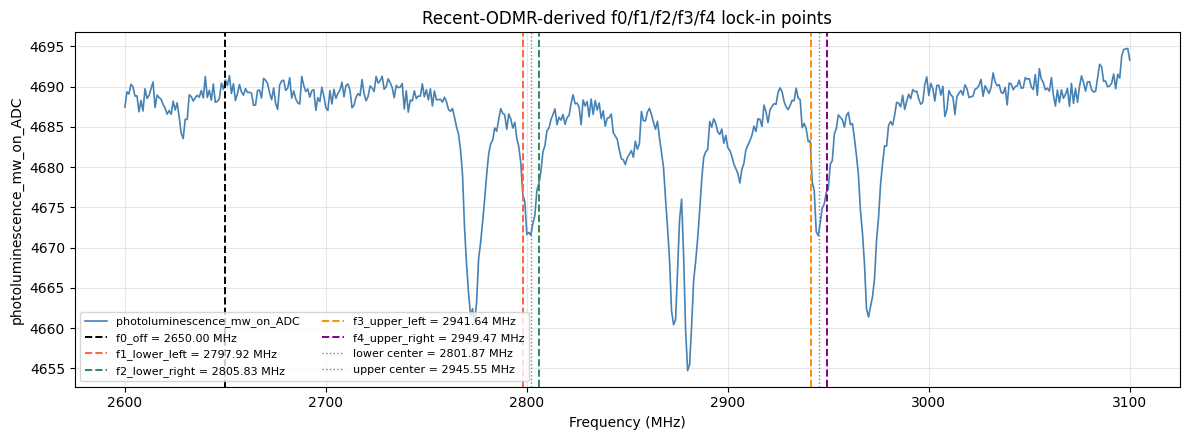

In [ ]:
from twopoint_lockin import run_twopoint_lockin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.signal import find_peaks as scipy_find_peaks, savgol_filter
from IPython.display import display

# --- Recent-ODMR-derived target points ---
# "latest" prefers the current in-memory sweep (`d`) if it spans the requested regions;
# otherwise it uses LAST_ODMR_CSV, then the newest odmr_sweep_*.csv in Initial Test.
MULTIPOINT_ODMR_SOURCE = "latest"      # "latest", "current", or a CSV path
MULTIPOINT_TRACE_COLUMN = "photoluminescence_mw_on_ADC"
MULTIPOINT_OFF_RESONANCE_TARGET_MHZ = 2650.0
MULTIPOINT_LOWER_TARGET_MHZ = 2810.0
MULTIPOINT_UPPER_TARGET_MHZ = 2939.0
MULTIPOINT_SEARCH_HALF_RANGE_MHZ = 35.0
MULTIPOINT_FIT_HALF_RANGE_MHZ = 20.0
MULTIPOINT_SLOPE_FRACTION = 0.5      # 0.5 = half-max points; 0.289 = Lorentzian max-slope points
LOCKIN_PLOT_HALF_WIDTH_MHZ = 18.0

# --- Acquisition defaults used by the cells below ---
LOCKIN_REPS_PER_BATCH = 10
LOCKIN_DURATION_SEC = 1.0
MULTIPOINT_REPS_PER_POINT = 10
MULTIPOINT_N_BATCHES = 1
MULTIPOINT_SIGNAL_DIFF_THRESHOLD_ADC = 1.0  # if |signal_left - signal_right| <= this, input midpoint as the peak


def _candidate_odmr_dirs():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        PROJECT_ROOT / "data" / "odmr_sweeps",
        PROJECT_ROOT / "data" / "lockin_twopoint",
        PROJECT_ROOT / "data" / "lockin_multipoint",
        PROJECT_ROOT / "data" / "calibration",
        cwd / "Initial Test",
        cwd.parent / "Initial Test",
        cwd.parent / "data" / "odmr_sweeps",
    ]
    unique = []
    for candidate in candidates:
        if candidate.exists() and candidate not in unique:
            unique.append(candidate)
    return unique


def _read_odmr_csv(path):
    path = Path(path).expanduser()
    if not path.is_absolute():
        for base in _candidate_odmr_dirs():
            candidate = base / path
            if candidate.exists():
                path = candidate
                break
    df = pd.read_csv(path)
    if "frequency_MHz" not in df.columns:
        df = df.rename(columns={df.columns[0]: "frequency_MHz"})
    return df, str(path.resolve())


def _current_odmr_dataframe():
    if "d" not in globals() or not hasattr(d, "frequencies"):
        return None, None
    df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    return df, "current in-memory ODMR sweep (`d`)"


def _covers_required_ranges(freqs_mhz, required_ranges):
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    freqs_mhz = freqs_mhz[np.isfinite(freqs_mhz)]
    if freqs_mhz.size == 0:
        return False
    f_min, f_max = float(np.min(freqs_mhz)), float(np.max(freqs_mhz))
    return all(f_min <= low and f_max >= high for low, high in required_ranges)


def _find_latest_odmr_csv(required_ranges):
    files = []
    for base in _candidate_odmr_dirs():
        files.extend(base.glob("odmr_sweep_*.csv"))
    files = sorted(set(files), key=lambda path: path.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError("No odmr_sweep_*.csv files found in the notebook directory or Initial Test")

    first_df, first_label = _read_odmr_csv(files[0])
    for path in files:
        df, label = _read_odmr_csv(path)
        if _covers_required_ranges(df["frequency_MHz"], required_ranges):
            return df, label
    print("Warning: no saved ODMR sweep spans all requested target windows; using newest sweep anyway.")
    return first_df, first_label


def _load_recent_odmr_dataframe(source, required_ranges):
    if source in (None, "latest", "current"):
        current_df, current_label = _current_odmr_dataframe()
        if current_df is not None and _covers_required_ranges(current_df["frequency_MHz"], required_ranges):
            return current_df, current_label
        if source == "current":
            raise ValueError("Current in-memory sweep (`d`) does not span the requested target windows")

    if source == "latest":
        if "LAST_ODMR_CSV" in globals() and LAST_ODMR_CSV is not None:
            try:
                df, label = _read_odmr_csv(LAST_ODMR_CSV)
                if _covers_required_ranges(df["frequency_MHz"], required_ranges):
                    return df, label
            except FileNotFoundError:
                pass
        return _find_latest_odmr_csv(required_ranges)

    return _read_odmr_csv(source)


def _choose_odmr_trace(df, preferred_column):
    if preferred_column in df.columns:
        return df[preferred_column].to_numpy(dtype=float), preferred_column
    for column in ("photoluminescence_mw_on_ADC", "photoluminescence_mw_off_ADC", "contrast_ADC", "contrast_percent"):
        if column in df.columns:
            return df[column].to_numpy(dtype=float), column
    return df.iloc[:, 1].to_numpy(dtype=float), df.columns[1]


def _smooth_for_minimum_selection(values):
    values = np.asarray(values, dtype=float)
    if len(values) < 7:
        return values
    window = min(9, len(values) if len(values) % 2 == 1 else len(values) - 1)
    if window < 5:
        return values
    return savgol_filter(values, window_length=window, polyorder=2, mode="interp")


def _local_minimum_index_near_target(freqs_mhz, trace, search_indices, target_mhz):
    search_indices = np.asarray(search_indices, dtype=int)
    if len(search_indices) < 3:
        return int(search_indices[np.argmin(trace[search_indices])])

    search_freqs = freqs_mhz[search_indices]
    search_trace_smooth = _smooth_for_minimum_selection(trace[search_indices])
    trend_order = 1 if len(search_indices) >= 3 else 0
    trend = np.polyval(np.polyfit(search_freqs, search_trace_smooth, trend_order), search_freqs)
    detrended = search_trace_smooth - trend
    prominence = max(float(np.std(detrended) * 0.8), float(np.ptp(detrended) * 0.08))
    prominent_rel, _ = scipy_find_peaks(-detrended, prominence=prominence, distance=3)
    if len(prominent_rel) > 0:
        prominent_indices = search_indices[prominent_rel]
        return int(prominent_indices[np.argmin(np.abs(freqs_mhz[prominent_indices] - target_mhz))])

    local_mask = np.zeros(len(search_indices), dtype=bool)
    local_mask[1:-1] = (search_trace_smooth[1:-1] <= search_trace_smooth[:-2]) & (search_trace_smooth[1:-1] <= search_trace_smooth[2:])
    local_indices = search_indices[local_mask]
    if len(local_indices) == 0:
        return int(search_indices[np.argmin(trace[search_indices])])
    return int(local_indices[np.argmin(np.abs(freqs_mhz[local_indices] - target_mhz))])


def _lorentzian_with_slope(f_mhz, f0_mhz, gamma_mhz, amplitude, offset, slope):
    return offset + slope * (f_mhz - f0_mhz) + amplitude * gamma_mhz**2 / (
        (f_mhz - f0_mhz) ** 2 + gamma_mhz**2
    )


def _fit_odmr_dip_near(freqs_mhz, trace, target_mhz, *, search_half_range_mhz, fit_half_range_mhz, fallback_fwhm_mhz=10.0, center_bound_half_range_mhz=6.0):
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    trace = np.asarray(trace, dtype=float)

    search_mask = (freqs_mhz >= target_mhz - search_half_range_mhz) & (freqs_mhz <= target_mhz + search_half_range_mhz)
    if search_mask.sum() < 5:
        raise ValueError(f"Not enough ODMR points near {target_mhz:.1f} MHz")

    search_indices = np.where(search_mask)[0]
    raw_idx = _local_minimum_index_near_target(freqs_mhz, trace, search_indices, target_mhz)
    raw_min_mhz = float(freqs_mhz[raw_idx])
    raw_min_adc = float(trace[raw_idx])

    fit_mask = (freqs_mhz >= raw_min_mhz - fit_half_range_mhz) & (freqs_mhz <= raw_min_mhz + fit_half_range_mhz)
    fit_freqs = freqs_mhz[fit_mask]
    fit_trace = trace[fit_mask]
    offset_guess = float(np.median(fit_trace))
    amplitude_guess = float(raw_min_adc - offset_guess)

    fit_ok = True
    try:
        center_low = max(float(fit_freqs.min()), raw_min_mhz - float(center_bound_half_range_mhz))
        center_high = min(float(fit_freqs.max()), raw_min_mhz + float(center_bound_half_range_mhz))
        popt, _ = curve_fit(
            _lorentzian_with_slope,
            fit_freqs,
            fit_trace,
            p0=[raw_min_mhz, max(0.1, 0.5 * fallback_fwhm_mhz), amplitude_guess, offset_guess, 0.0],
            bounds=(
                [center_low, 0.05, -np.inf, -np.inf, -np.inf],
                [center_high, 80.0, 0.0, np.inf, np.inf],
            ),
            maxfev=200000,
        )
        center_mhz, gamma_mhz, amplitude, offset, slope = [float(v) for v in popt]
        fwhm_mhz = 2.0 * gamma_mhz
        if not np.isfinite(center_mhz) or not np.isfinite(fwhm_mhz) or fwhm_mhz <= 0:
            fit_ok = False
    except Exception:
        fit_ok = False

    if not fit_ok:
        center_mhz = raw_min_mhz
        fwhm_mhz = float(fallback_fwhm_mhz)
        amplitude = amplitude_guess
        offset = offset_guess
        slope = 0.0

    return {
        "requested_mhz": float(target_mhz),
        "raw_min_mhz": raw_min_mhz,
        "raw_min_adc": raw_min_adc,
        "center_mhz": center_mhz,
        "fwhm_mhz": fwhm_mhz,
        "amplitude_adc": float(amplitude),
        "baseline_adc": float(offset),
        "baseline_slope_adc_per_mhz": float(slope),
        "fit_ok": bool(fit_ok),
    }


_required_ranges = [
    (MULTIPOINT_OFF_RESONANCE_TARGET_MHZ - 10.0, MULTIPOINT_OFF_RESONANCE_TARGET_MHZ + 10.0),
    (MULTIPOINT_LOWER_TARGET_MHZ - MULTIPOINT_SEARCH_HALF_RANGE_MHZ, MULTIPOINT_LOWER_TARGET_MHZ + MULTIPOINT_SEARCH_HALF_RANGE_MHZ),
    (MULTIPOINT_UPPER_TARGET_MHZ - MULTIPOINT_SEARCH_HALF_RANGE_MHZ, MULTIPOINT_UPPER_TARGET_MHZ + MULTIPOINT_SEARCH_HALF_RANGE_MHZ),
]
_peak_df, _odmr_source_label = _load_recent_odmr_dataframe(MULTIPOINT_ODMR_SOURCE, _required_ranges)
_csv_freqs = _peak_df["frequency_MHz"].to_numpy(dtype=float)
_csv_trace, _trace_label = _choose_odmr_trace(_peak_df, MULTIPOINT_TRACE_COLUMN)

_lower_peak = _fit_odmr_dip_near(
    _csv_freqs,
    _csv_trace,
    MULTIPOINT_LOWER_TARGET_MHZ,
    search_half_range_mhz=MULTIPOINT_SEARCH_HALF_RANGE_MHZ,
    fit_half_range_mhz=MULTIPOINT_FIT_HALF_RANGE_MHZ,
)
_upper_peak = _fit_odmr_dip_near(
    _csv_freqs,
    _csv_trace,
    MULTIPOINT_UPPER_TARGET_MHZ,
    search_half_range_mhz=MULTIPOINT_SEARCH_HALF_RANGE_MHZ,
    fit_half_range_mhz=MULTIPOINT_FIT_HALF_RANGE_MHZ,
)

F0_OFF_RESONANCE_MHZ = float(_csv_freqs[np.argmin(np.abs(_csv_freqs - MULTIPOINT_OFF_RESONANCE_TARGET_MHZ))])
LOWER_PEAK_CENTER_MHZ = _lower_peak["center_mhz"]
LOWER_PEAK_FWHM_MHZ = _lower_peak["fwhm_mhz"]
UPPER_PEAK_CENTER_MHZ = _upper_peak["center_mhz"]
UPPER_PEAK_FWHM_MHZ = _upper_peak["fwhm_mhz"]

F1_LOWER_LEFT_MHZ = LOWER_PEAK_CENTER_MHZ - MULTIPOINT_SLOPE_FRACTION * LOWER_PEAK_FWHM_MHZ
F2_LOWER_RIGHT_MHZ = LOWER_PEAK_CENTER_MHZ + MULTIPOINT_SLOPE_FRACTION * LOWER_PEAK_FWHM_MHZ
F3_UPPER_LEFT_MHZ = UPPER_PEAK_CENTER_MHZ - MULTIPOINT_SLOPE_FRACTION * UPPER_PEAK_FWHM_MHZ
F4_UPPER_RIGHT_MHZ = UPPER_PEAK_CENTER_MHZ + MULTIPOINT_SLOPE_FRACTION * UPPER_PEAK_FWHM_MHZ

MULTIPOINT_FREQUENCY_TABLE = pd.DataFrame(
    [
        {"label": "f0_off", "role": "off-resonance baseline", "frequency_MHz": F0_OFF_RESONANCE_MHZ},
        {"label": "f1_lower_left", "role": "lower peak left slope", "frequency_MHz": F1_LOWER_LEFT_MHZ},
        {"label": "f2_lower_right", "role": "lower peak right slope", "frequency_MHz": F2_LOWER_RIGHT_MHZ},
        {"label": "f3_upper_left", "role": "upper peak left slope", "frequency_MHz": F3_UPPER_LEFT_MHZ},
        {"label": "f4_upper_right", "role": "upper peak right slope", "frequency_MHz": F4_UPPER_RIGHT_MHZ},
    ]
)

# Keep the older two-point cells below compatible: they target the lower recent-ODMR-derived feature.
LOCKIN_TARGET_MHZ = LOWER_PEAK_CENTER_MHZ
LOCKIN_CENTER_MHZ = LOWER_PEAK_CENTER_MHZ
LOCKIN_FWHM_MHZ = LOWER_PEAK_FWHM_MHZ
LOCKIN_MANUAL_FWHM_MHZ = LOWER_PEAK_FWHM_MHZ
LOCKIN_CENTER_SOURCE = f"Recent ODMR {MULTIPOINT_TRACE_COLUMN} Lorentzian fit near requested {MULTIPOINT_LOWER_TARGET_MHZ:.0f} MHz region"
LOCKIN_CSV = str(data_path("twopoint", f"twopoint_lockin_lower_{LOCKIN_CENTER_MHZ:.0f}MHz_peak.csv"))
MULTIPOINT_CSV = str(data_path("multipoint", f"multipoint_lockin_f0_{F0_OFF_RESONANCE_MHZ:.0f}_lower_{LOWER_PEAK_CENTER_MHZ:.0f}_upper_{UPPER_PEAK_CENTER_MHZ:.0f}.csv"))

_f1 = F1_LOWER_LEFT_MHZ
_f2 = F2_LOWER_RIGHT_MHZ
_body_tus = 2 * default_config.readout_integration_tus + 2 * default_config.relax_delay_tus
_cycle_tus = 2 * _body_tus

_off_mask = np.abs(_csv_freqs - F0_OFF_RESONANCE_MHZ) <= 10.0
_off_slope = float(np.polyfit(_csv_freqs[_off_mask], _csv_trace[_off_mask], 1)[0]) if _off_mask.sum() >= 3 else np.nan
_off_std = float(np.std(_csv_trace[_off_mask], ddof=1)) if _off_mask.sum() >= 3 else np.nan

print(f"ODMR source: {_odmr_source_label}")
print(f"Trace column for parked-point selection: {_trace_label}")
print(f"f0 off-resonance: requested {MULTIPOINT_OFF_RESONANCE_TARGET_MHZ:.1f} MHz -> ODMR point {F0_OFF_RESONANCE_MHZ:.6f} MHz")
print(f"  local +/-10 MHz flatness: std={_off_std:.4f} ADC, slope={_off_slope:.4f} ADC/MHz")
print(f"Lower requested region {MULTIPOINT_LOWER_TARGET_MHZ:.1f} MHz -> raw min {_lower_peak['raw_min_mhz']:.6f} MHz, fit center {LOWER_PEAK_CENTER_MHZ:.6f} MHz, FWHM {LOWER_PEAK_FWHM_MHZ:.6f} MHz")
print(f"Upper requested region {MULTIPOINT_UPPER_TARGET_MHZ:.1f} MHz -> raw min {_upper_peak['raw_min_mhz']:.6f} MHz, fit center {UPPER_PEAK_CENTER_MHZ:.6f} MHz, FWHM {UPPER_PEAK_FWHM_MHZ:.6f} MHz")
print(f"Hardware f1<->f2 two-point rate: {1e6/_cycle_tus:.0f} Hz ({_cycle_tus:.0f} us/cycle)")
print(f"Five-point CSV output: {MULTIPOINT_CSV}")

display(MULTIPOINT_FREQUENCY_TABLE)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(_csv_freqs, _csv_trace, color="steelblue", lw=1.2, label=_trace_label)
colors = {
    "f0_off": "black",
    "f1_lower_left": "tomato",
    "f2_lower_right": "seagreen",
    "f3_upper_left": "darkorange",
    "f4_upper_right": "purple",
}
for row in MULTIPOINT_FREQUENCY_TABLE.itertuples(index=False):
    ax.axvline(row.frequency_MHz, color=colors[row.label], ls="--", lw=1.4, label=f"{row.label} = {row.frequency_MHz:.2f} MHz")
ax.axvline(LOWER_PEAK_CENTER_MHZ, color="gray", ls=":", lw=1.0, label=f"lower center = {LOWER_PEAK_CENTER_MHZ:.2f} MHz")
ax.axvline(UPPER_PEAK_CENTER_MHZ, color="slategray", ls=":", lw=1.0, label=f"upper center = {UPPER_PEAK_CENTER_MHZ:.2f} MHz")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(_trace_label)
ax.set_title("Recent-ODMR-derived f0/f1/f2/f3/f4 lock-in points")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)
plt.close(fig)


### Five-Frequency Acquisition: f0 + Two Peak Pairs

Run this cell to acquire f0, f1, f2, f3, and f4 sequentially. This supports arbitrary frequencies, so it can use the off-resonance point and both CSV-derived peak pairs.

This is not a hardware-rate arbitrary-frequency sweep; each point is acquired as its own one-frequency ODMR measurement. It is meant for testing and comparing the two peak pairs cleanly.


In [ ]:
# Sequential single-shot five-frequency measurement using the CSV-derived f0/f1/f2/f3/f4 table.
# Each point is acquired as a zero-span LockinODMR measurement, so arbitrary frequencies are supported.
from copy import copy
from time import perf_counter
import numpy as np
import pandas as pd
from IPython.display import FileLink, display


def run_multipoint_lockin(
    config,
    frequency_table,
    *,
    reps_per_point=10,
    n_batches=1,
    signal_diff_threshold_adc=1.0,
    csv_filename=None,
):
    frequency_rows = list(frequency_table.to_dict("records"))
    rows = []
    t0 = perf_counter()

    print("Single-shot five-frequency lock-in test")
    print(f"  reps per point: {reps_per_point}")
    print(f"  batches: {n_batches}")
    print(f"  midpoint threshold: |signal_left - signal_right| <= {signal_diff_threshold_adc:.5f} ADC")
    print(f"  f0 reference/off-resonance: {F0_OFF_RESONANCE_MHZ:.6f} MHz")
    print("  sequence: " + " -> ".join(f"{row['label']}={row['frequency_MHz']:.3f}" for row in frequency_rows))
    print()

    for batch in range(int(n_batches)):
        row_out = {"batch": batch, "time_s": perf_counter() - t0}

        for row in frequency_rows:
            label = row["label"]
            freq_mhz = float(row["frequency_MHz"])

            cfg = copy(config)
            cfg.mw_start_fMHz = freq_mhz
            cfg.mw_end_fMHz = freq_mhz
            # QickSweep divides by (nsweep_points - 1), so a true one-point sweep faults.
            # Use a two-point zero-span sweep and average the two identical-frequency results.
            cfg.nsweep_points = 2
            cfg.reps = int(reps_per_point)
            cfg.pre_init = getattr(config, "pre_init", True)
            cfg.odmr_reference_offres_mhz = F0_OFF_RESONANCE_MHZ

            prog = qd.LockinODMR(cfg)
            d_point = prog.acquire(progress=False)

            signal = float(np.mean(np.asarray(d_point.signal, dtype=float)))
            reference = float(np.mean(np.asarray(d_point.reference, dtype=float)))
            contrast = float(np.mean(np.asarray(d_point.contrast, dtype=float)))
            contrast_percent = float(np.mean(np.asarray(d_point.contrast_percent, dtype=float)))

            row_out[f"{label}_freq_mhz"] = freq_mhz
            row_out[f"{label}_signal"] = signal
            row_out[f"{label}_reference"] = reference
            row_out[f"{label}_contrast"] = contrast
            row_out[f"{label}_contrast_percent"] = contrast_percent

        row_out["lower_lockin_signal"] = row_out["f1_lower_left_signal"] - row_out["f2_lower_right_signal"]
        row_out["upper_lockin_signal"] = row_out["f3_upper_left_signal"] - row_out["f4_upper_right_signal"]
        row_out["lower_lockin_contrast"] = row_out["f1_lower_left_contrast"] - row_out["f2_lower_right_contrast"]
        row_out["upper_lockin_contrast"] = row_out["f3_upper_left_contrast"] - row_out["f4_upper_right_contrast"]
        row_out["lower_abs_signal_diff"] = abs(row_out["lower_lockin_signal"])
        row_out["upper_abs_signal_diff"] = abs(row_out["upper_lockin_signal"])
        row_out["lower_midpoint_threshold_met"] = row_out["lower_abs_signal_diff"] <= float(signal_diff_threshold_adc)
        row_out["upper_midpoint_threshold_met"] = row_out["upper_abs_signal_diff"] <= float(signal_diff_threshold_adc)
        row_out["lower_peak_input_mhz"] = (
            0.5 * (row_out["f1_lower_left_freq_mhz"] + row_out["f2_lower_right_freq_mhz"])
            if row_out["lower_midpoint_threshold_met"] else np.nan
        )
        row_out["upper_peak_input_mhz"] = (
            0.5 * (row_out["f3_upper_left_freq_mhz"] + row_out["f4_upper_right_freq_mhz"])
            if row_out["upper_midpoint_threshold_met"] else np.nan
        )
        row_out["f1_minus_f0_signal"] = row_out["f1_lower_left_signal"] - row_out["f0_off_signal"]
        row_out["f2_minus_f0_signal"] = row_out["f2_lower_right_signal"] - row_out["f0_off_signal"]
        row_out["f3_minus_f0_signal"] = row_out["f3_upper_left_signal"] - row_out["f0_off_signal"]
        row_out["f4_minus_f0_signal"] = row_out["f4_upper_right_signal"] - row_out["f0_off_signal"]
        rows.append(row_out)

        print(
            f"batch {batch + 1}/{int(n_batches)}: "
            f"lower={row_out['lower_lockin_signal']:.5f} ADC, "
            f"upper={row_out['upper_lockin_signal']:.5f} ADC, "
            f"f0={row_out['f0_off_signal']:.5f} ADC, "
            f"lower_peak_input={row_out['lower_peak_input_mhz']}, "
            f"upper_peak_input={row_out['upper_peak_input_mhz']}"
        )

    df_out = pd.DataFrame(rows)

    if csv_filename is not None and not df_out.empty:
        df_out.to_csv(csv_filename, index=False)
        print(f"Saved {len(df_out)} rows to {csv_filename}")
        display(FileLink(csv_filename))

    return df_out


df_multipoint = run_multipoint_lockin(
    default_config,
    MULTIPOINT_FREQUENCY_TABLE,
    reps_per_point=MULTIPOINT_REPS_PER_POINT,
    n_batches=MULTIPOINT_N_BATCHES,
    signal_diff_threshold_adc=MULTIPOINT_SIGNAL_DIFF_THRESHOLD_ADC,
    csv_filename=MULTIPOINT_CSV,
)

display(df_multipoint)

# Convenience view: one row per f0/f1/f2/f3/f4 point from the first single-shot batch.
if not df_multipoint.empty:
    _first = df_multipoint.iloc[0]
    df_multipoint_single_shot = pd.DataFrame(
        [
            {
                "label": row.label,
                "role": row.role,
                "frequency_MHz": _first[f"{row.label}_freq_mhz"],
                "signal": _first[f"{row.label}_signal"],
                "reference": _first[f"{row.label}_reference"],
                "contrast": _first[f"{row.label}_contrast"],
                "contrast_percent": _first[f"{row.label}_contrast_percent"],
                "signal_minus_f0": 0.0 if row.label == "f0_off" else _first[f"{row.label}_signal"] - _first["f0_off_signal"],
            }
            for row in MULTIPOINT_FREQUENCY_TABLE.itertuples(index=False)
        ]
    )
    df_peak_inputs = pd.DataFrame(
        [
            {
                "pair": "lower_f1_f2",
                "abs_signal_diff": _first["lower_abs_signal_diff"],
                "threshold_adc": MULTIPOINT_SIGNAL_DIFF_THRESHOLD_ADC,
                "threshold_met": _first["lower_midpoint_threshold_met"],
                "peak_input_mhz": _first["lower_peak_input_mhz"],
            },
            {
                "pair": "upper_f3_f4",
                "abs_signal_diff": _first["upper_abs_signal_diff"],
                "threshold_adc": MULTIPOINT_SIGNAL_DIFF_THRESHOLD_ADC,
                "threshold_met": _first["upper_midpoint_threshold_met"],
                "peak_input_mhz": _first["upper_peak_input_mhz"],
            },
        ]
    )
    display(df_multipoint_single_shot)
    display(df_peak_inputs)


Single-shot five-frequency lock-in test
  reps per point: 1000
  batches: 1
  midpoint threshold: |signal_left - signal_right| <= 1.00000 ADC
  f0 reference/off-resonance: 2649.999981 MHz
  sequence: f0_off=2650.000 -> f1_lower_left=2797.920 -> f2_lower_right=2805.826 -> f3_upper_left=2941.637 -> f4_upper_right=2949.470

batch 1/1: lower=0.15371 ADC, upper=-0.08955 ADC, f0=4704.16900 ADC, lower_peak_input=2801.872938004124, upper_peak_input=2945.55383153408
Saved 1 rows to multipoint_lockin_f0_2650_lower_2802_upper_2946.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/multipoint_lockin_f0_2650_lower_2802_upper_2946.csv

,batch,time_s,f0_off_freq_mhz,f0_off_signal,f0_off_reference,f0_off_contrast,f0_off_contrast_percent,f1_lower_left_freq_mhz,f1_lower_left_signal,f1_lower_left_reference,...,lower_abs_signal_diff,upper_abs_signal_diff,lower_midpoint_threshold_met,upper_midpoint_threshold_met,lower_peak_input_mhz,upper_peak_input_mhz,f1_minus_f0_signal,f2_minus_f0_signal,f3_minus_f0_signal,f4_minus_f0_signal
0,0,0.000288,2649.999981,4704.169002,4704.645769,-0.476767,-0.010111,2797.919974,4700.94403,4699.926495,...,0.153708,0.089546,True,True,2801.872938,2945.553832,-3.224972,-3.37868,-1.218666,-1.12912


,label,role,frequency_MHz,signal,reference,contrast,contrast_percent,signal_minus_f0
0,f0_off,off-resonance baseline,2649.999981,4704.169002,4704.645769,-0.476767,-0.010111,0.000000
1,f1_lower_left,lower peak left slope,2797.919974,4700.944030,4699.926495,1.017535,0.021698,-3.224972
2,f2_lower_right,lower peak right slope,2805.825902,4700.790323,4699.704614,1.085709,0.023149,-3.378680
3,f3_upper_left,upper peak left slope,2941.637451,4702.950337,4702.335661,0.614676,0.013099,-1.218666
4,f4_upper_right,upper peak right slope,2949.470212,4703.039883,4702.443927,0.595956,0.012700,-1.129120


,pair,abs_signal_diff,threshold_adc,threshold_met,peak_input_mhz
0,lower_f1_f2,0.153708,1.0,True,2801.872938
1,upper_f3_f4,0.089546,1.0,True,2945.553832


### Eight-Peak Parked Acquisition For Vector Field Reconstruction

Run this before the Yizhou analysis cell when you want full vector reconstruction. It creates 8 two-point parked blocks by fitting the most recent ODMR sweep near the calibrated transition order, so each batch measures 16 frequencies total.

Yizhou's full-scan fit is still used for the bias field and NV-axis/channel ordering. The actual parked center/FWHM/flank frequencies are taken from the current/recent ODMR sweep, not from the old `8_peaks...csv` trace.

Four parked frequencies only give two scalar projections. That is enough for per-channel projected field, and enough for a constrained scalar field if you assume a known direction, but it is not enough for unconstrained `delta_Bx`, `delta_By`, `delta_Bz`.


8-peak parked-frequency table: 16 flank frequencies = 8 blocks x 2 flanks.
ODMR source for parked-point selection: current in-memory ODMR sweep (`d`)
Trace column for parked-point selection: photoluminescence_mw_on_ADC
Yizhou's reference fit is still used for bias field and NV-axis/channel ordering; recent ODMR is used for center/FWHM/flank frequencies.
Acquisition will also measure f0_off = 2649.999981 MHz for the display-only signal_minus_f0 column.
The Yizhou parked inversion still uses only the 16 flank frequencies; f0_off columns are ignored by the converter.
Output CSV when acquired: multipoint_lockin_8peaks_16freq_recent_odmr.csv



,label,role,block_index,point_in_block,transition_center_MHz,frequency_MHz
0,f01_b01_minus,block 01 lower flank,1,1,2773.181095,2768.151919
1,f02_b01_plus,block 01 upper flank,1,2,2773.181095,2778.210271
2,f03_b02_minus,block 02 lower flank,2,1,2801.737819,2796.759578
3,f04_b02_plus,block 02 upper flank,2,2,2801.737819,2806.716061
4,f05_b03_minus,block 03 lower flank,3,1,2850.071069,2842.514288
5,f06_b03_plus,block 03 upper flank,3,2,2850.071069,2857.627850
6,f07_b04_minus,block 04 lower flank,4,1,2873.306948,2869.851204
7,f08_b04_plus,block 04 upper flank,4,2,2873.306948,2876.762692
8,f09_b05_minus,block 05 lower flank,5,1,2882.999892,2878.832989
9,f10_b05_plus,block 05 upper flank,5,2,2882.999892,2887.166796


,block_index,target_center_mhz,raw_min_mhz,transition_center_mhz,frequency_minus_mhz,frequency_plus_mhz,linewidth_mhz,axis_index,transition_side,search_half_range_mhz,fit_ok
0,1,2764.314151,2771.999935,2773.181095,2768.151919,2778.210271,10.058352,1,0,14.702116,True
1,2,2796.985520,2800.999924,2801.737819,2796.759578,2806.716061,9.956483,2,0,14.702116,True
2,3,2842.220515,2847.999906,2850.071069,2842.514288,2857.627850,15.113562,0,0,13.779965,True
3,4,2872.842660,2872.999896,2873.306948,2869.851204,2876.762692,6.911489,3,0,4.561828,True
4,5,2882.980056,2882.999892,2882.999892,2878.832989,2887.166796,8.333807,3,1,4.561828,False
5,6,2911.322373,2905.999884,2905.613997,2901.016340,2910.211653,9.195313,0,1,12.754043,True
6,7,2952.989002,2945.999868,2945.841074,2940.243942,2951.438206,11.194264,2,1,11.938256,True
7,8,2979.518461,2971.999858,2970.451752,2965.096673,2975.806831,10.710159,1,1,11.938256,True


Runtime note: this measures 17 frequencies per batch (16 parked flanks + 1 f0 baseline).
That is 3.4x the point count of the old f0/f1/f2/f3/f4 cell.
Approximate pulse-time lower bound: 14.52 s for 1000 reps/point and 1 batch(es).
Actual runtime is longer because the acquisition loop starts one zero-span LockinODMR program for each parked frequency.
For a quick test, lower MULTIPOINT_8PEAK_REPS_PER_POINT before setting RUN_8PEAK_ACQUISITION = True.


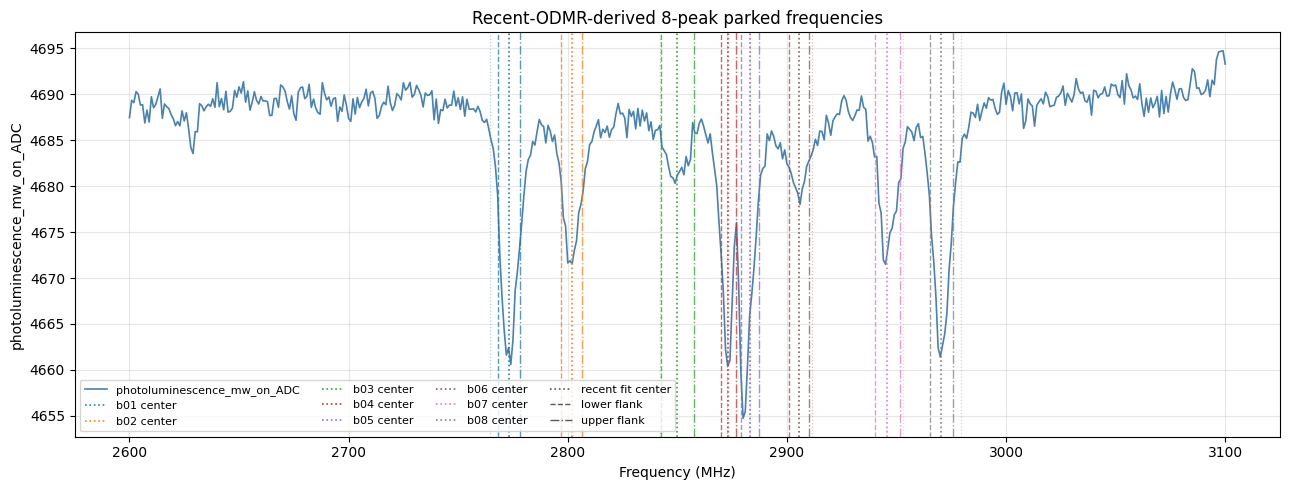

Parked-frequency lock-in acquisition
  parked flank points per batch: 16
  total acquired points per batch: 17
  blocks: 8
  reps per point: 1000
  batches: 1
  midpoint threshold: |signal_minus - signal_plus| <= 1.00000 ADC
  f0 reference/off-resonance: 2649.999981 MHz
  sequence: f0_off=2650.000 -> f01_b01_minus=2768.152 -> f02_b01_plus=2778.210 -> f03_b02_minus=2796.760 -> f04_b02_plus=2806.716 -> f05_b03_minus=2842.514 -> f06_b03_plus=2857.628 -> f07_b04_minus=2869.851 -> f08_b04_plus=2876.763 -> f09_b05_minus=2878.833 -> f10_b05_plus=2887.167 -> f11_b06_minus=2901.016 -> f12_b06_plus=2910.212 -> f13_b07_minus=2940.244 -> f14_b07_plus=2951.438 -> f15_b08_minus=2965.097 -> f16_b08_plus=2975.807



KeyboardInterrupt: 

In [30]:
# Build and optionally acquire the 8-peak / 16-frequency parked measurement.
# Default is preview-only so this cell is fast and does not start hardware acquisition.
from copy import copy
from time import perf_counter, time
import importlib
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplcache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks as scipy_find_peaks, savgol_filter
from IPython.display import FileLink, display

RUN_8PEAK_ACQUISITION = True
MULTIPOINT_8PEAK_REPS_PER_POINT = MULTIPOINT_REPS_PER_POINT if "MULTIPOINT_REPS_PER_POINT" in globals() else 1000
MULTIPOINT_8PEAK_N_BATCHES = MULTIPOINT_N_BATCHES if "MULTIPOINT_N_BATCHES" in globals() else 1
MULTIPOINT_8PEAK_SIGNAL_DIFF_THRESHOLD_ADC = MULTIPOINT_SIGNAL_DIFF_THRESHOLD_ADC if "MULTIPOINT_SIGNAL_DIFF_THRESHOLD_ADC" in globals() else 1.0
MULTIPOINT_8PEAK_MEASURE_F0_OFF = True
MULTIPOINT_8PEAK_OFF_RESONANCE_MHZ = F0_OFF_RESONANCE_MHZ if "F0_OFF_RESONANCE_MHZ" in globals() else 2650.0
MULTIPOINT_8PEAK_CSV = str(data_path("multipoint", "multipoint_lockin_8peaks_16freq_recent_odmr.csv"))
EIGHTPEAK_ODMR_SOURCE = "latest"      # "latest", "current", or a CSV path
EIGHTPEAK_TRACE_COLUMN = "photoluminescence_mw_on_ADC"
EIGHTPEAK_SEARCH_HALF_RANGE_MHZ = 25.0
EIGHTPEAK_FIT_HALF_RANGE_MHZ = 12.0
EIGHTPEAK_SLOPE_FRACTION = 0.5
EIGHTPEAK_MAX_FWHM_MHZ = 35.0


def _find_nv_magnetometry_repo_for_8peak():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        *cwd.parents,
        cwd / "NV_Magnetometry_Software-main",
        cwd.parent / "NV_Magnetometry_Software-main",
    ]
    for candidate in candidates:
        if (candidate / "nv_toolkit").exists() and (candidate / "phase1" / "analyze_multipeak_parked_measurement.py").exists():
            return candidate
        if (candidate / "analyze_multipeak_parked_measurement.py").exists() and (candidate.parent / "nv_toolkit").exists():
            return candidate.parent
    raise FileNotFoundError("Could not find NV_Magnetometry_Software-main from the current notebook directory")


def _candidate_odmr_dirs():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        PROJECT_ROOT / "data" / "odmr_sweeps",
        PROJECT_ROOT / "data" / "lockin_twopoint",
        PROJECT_ROOT / "data" / "lockin_multipoint",
        PROJECT_ROOT / "data" / "calibration",
        cwd / "Initial Test",
        cwd.parent / "Initial Test",
        cwd.parent / "data" / "odmr_sweeps",
    ]
    unique = []
    for candidate in candidates:
        if candidate.exists() and candidate not in unique:
            unique.append(candidate)
    return unique


def _read_odmr_csv(path):
    path = Path(path).expanduser()
    if not path.is_absolute():
        for base in _candidate_odmr_dirs():
            candidate = base / path
            if candidate.exists():
                path = candidate
                break
    df = pd.read_csv(path)
    if "frequency_MHz" not in df.columns:
        df = df.rename(columns={df.columns[0]: "frequency_MHz"})
    return df, str(path.resolve())


def _current_odmr_dataframe():
    if "d" not in globals() or not hasattr(d, "frequencies"):
        return None, None
    df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    return df, "current in-memory ODMR sweep (`d`)"


def _covers_required_ranges(freqs_mhz, required_ranges):
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    freqs_mhz = freqs_mhz[np.isfinite(freqs_mhz)]
    if freqs_mhz.size == 0:
        return False
    f_min, f_max = float(np.min(freqs_mhz)), float(np.max(freqs_mhz))
    return all(f_min <= low and f_max >= high for low, high in required_ranges)


def _find_latest_odmr_csv(required_ranges):
    files = []
    for base in _candidate_odmr_dirs():
        files.extend(base.glob("odmr_sweep_*.csv"))
    files = sorted(set(files), key=lambda path: path.stat().st_mtime, reverse=True)
    if not files:
        raise FileNotFoundError("No odmr_sweep_*.csv files found in the notebook directory or Initial Test")

    first_df, first_label = _read_odmr_csv(files[0])
    for path in files:
        df, label = _read_odmr_csv(path)
        if _covers_required_ranges(df["frequency_MHz"], required_ranges):
            return df, label
    print("Warning: no saved ODMR sweep spans all 8 transition target windows; using newest sweep anyway.")
    return first_df, first_label


def _load_recent_odmr_dataframe(source, required_ranges):
    if source in (None, "latest", "current"):
        current_df, current_label = _current_odmr_dataframe()
        if current_df is not None and _covers_required_ranges(current_df["frequency_MHz"], required_ranges):
            return current_df, current_label
        if source == "current":
            raise ValueError("Current in-memory sweep (`d`) does not span the 8 transition target windows")

    if source == "latest":
        if "LAST_ODMR_CSV" in globals() and LAST_ODMR_CSV is not None:
            try:
                df, label = _read_odmr_csv(LAST_ODMR_CSV)
                if _covers_required_ranges(df["frequency_MHz"], required_ranges):
                    return df, label
            except FileNotFoundError:
                pass
        return _find_latest_odmr_csv(required_ranges)

    return _read_odmr_csv(source)


def _choose_odmr_trace(df, preferred_column):
    if preferred_column in df.columns:
        return df[preferred_column].to_numpy(dtype=float), preferred_column
    for column in ("photoluminescence_mw_on_ADC", "photoluminescence_mw_off_ADC", "contrast_ADC", "contrast_percent"):
        if column in df.columns:
            return df[column].to_numpy(dtype=float), column
    return df.iloc[:, 1].to_numpy(dtype=float), df.columns[1]


def _smooth_for_minimum_selection(values):
    values = np.asarray(values, dtype=float)
    if len(values) < 7:
        return values
    window = min(9, len(values) if len(values) % 2 == 1 else len(values) - 1)
    if window < 5:
        return values
    return savgol_filter(values, window_length=window, polyorder=2, mode="interp")


def _local_minimum_index_near_target(freqs_mhz, trace, search_indices, target_mhz):
    search_indices = np.asarray(search_indices, dtype=int)
    if len(search_indices) < 3:
        return int(search_indices[np.argmin(trace[search_indices])])

    search_freqs = freqs_mhz[search_indices]
    search_trace_smooth = _smooth_for_minimum_selection(trace[search_indices])
    trend_order = 1 if len(search_indices) >= 3 else 0
    trend = np.polyval(np.polyfit(search_freqs, search_trace_smooth, trend_order), search_freqs)
    detrended = search_trace_smooth - trend
    prominence = max(float(np.std(detrended) * 0.8), float(np.ptp(detrended) * 0.08))
    prominent_rel, _ = scipy_find_peaks(-detrended, prominence=prominence, distance=3)
    if len(prominent_rel) > 0:
        prominent_indices = search_indices[prominent_rel]
        return int(prominent_indices[np.argmin(np.abs(freqs_mhz[prominent_indices] - target_mhz))])

    local_mask = np.zeros(len(search_indices), dtype=bool)
    local_mask[1:-1] = (search_trace_smooth[1:-1] <= search_trace_smooth[:-2]) & (search_trace_smooth[1:-1] <= search_trace_smooth[2:])
    local_indices = search_indices[local_mask]
    if len(local_indices) == 0:
        return int(search_indices[np.argmin(trace[search_indices])])
    return int(local_indices[np.argmin(np.abs(freqs_mhz[local_indices] - target_mhz))])


def _lorentzian_with_slope(f_mhz, f0_mhz, gamma_mhz, amplitude, offset, slope):
    return offset + slope * (f_mhz - f0_mhz) + amplitude * gamma_mhz**2 / (
        (f_mhz - f0_mhz) ** 2 + gamma_mhz**2
    )


def _fit_recent_odmr_dip_near(freqs_mhz, trace, target_mhz, *, search_half_range_mhz, fit_half_range_mhz, fallback_fwhm_mhz, center_bound_half_range_mhz=5.0):
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    trace = np.asarray(trace, dtype=float)

    search_mask = (freqs_mhz >= target_mhz - search_half_range_mhz) & (freqs_mhz <= target_mhz + search_half_range_mhz)
    if search_mask.sum() < 5:
        raise ValueError(f"Not enough recent ODMR points near {target_mhz:.1f} MHz")

    search_indices = np.where(search_mask)[0]
    raw_idx = _local_minimum_index_near_target(freqs_mhz, trace, search_indices, target_mhz)
    raw_min_mhz = float(freqs_mhz[raw_idx])
    raw_min_adc = float(trace[raw_idx])

    fit_mask = (freqs_mhz >= raw_min_mhz - fit_half_range_mhz) & (freqs_mhz <= raw_min_mhz + fit_half_range_mhz)
    fit_freqs = freqs_mhz[fit_mask]
    fit_trace = trace[fit_mask]
    offset_guess = float(np.median(fit_trace))
    amplitude_guess = float(raw_min_adc - offset_guess)

    fit_ok = True
    try:
        center_low = max(float(fit_freqs.min()), raw_min_mhz - float(center_bound_half_range_mhz))
        center_high = min(float(fit_freqs.max()), raw_min_mhz + float(center_bound_half_range_mhz))
        popt, _ = curve_fit(
            _lorentzian_with_slope,
            fit_freqs,
            fit_trace,
            p0=[raw_min_mhz, max(0.1, 0.5 * float(fallback_fwhm_mhz)), amplitude_guess, offset_guess, 0.0],
            bounds=(
                [center_low, 0.05, -np.inf, -np.inf, -np.inf],
                [center_high, 80.0, 0.0, np.inf, np.inf],
            ),
            maxfev=200000,
        )
        center_mhz, gamma_mhz, amplitude, offset, slope = [float(v) for v in popt]
        fwhm_mhz = 2.0 * gamma_mhz
        if (
            not np.isfinite(center_mhz)
            or not np.isfinite(fwhm_mhz)
            or fwhm_mhz <= 0
            or fwhm_mhz > EIGHTPEAK_MAX_FWHM_MHZ
            or abs(center_mhz - raw_min_mhz) > search_half_range_mhz
            or abs(center_mhz - raw_min_mhz) >= 0.9 * float(center_bound_half_range_mhz)
        ):
            fit_ok = False
    except Exception:
        fit_ok = False

    if not fit_ok:
        center_mhz = raw_min_mhz
        fwhm_mhz = float(fallback_fwhm_mhz)
        amplitude = amplitude_guess
        offset = offset_guess
        slope = 0.0

    return {
        "target_mhz": float(target_mhz),
        "raw_min_mhz": raw_min_mhz,
        "raw_min_adc": raw_min_adc,
        "center_mhz": float(center_mhz),
        "fwhm_mhz": float(fwhm_mhz),
        "amplitude_adc": float(amplitude),
        "baseline_adc": float(offset),
        "baseline_slope_adc_per_mhz": float(slope),
        "fit_ok": bool(fit_ok),
    }


NV_REPO_DIR = _find_nv_magnetometry_repo_for_8peak()
for path in (NV_REPO_DIR, NV_REPO_DIR / "phase1"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import analyze_multipeak_parked_measurement as mp
mp = importlib.reload(mp)

_ip = get_ipython() if "get_ipython" in globals() else None
if _ip is not None:
    _ip.run_line_magic("matplotlib", "inline")

reference_summary = mp.ensure_reference_outputs()
base_channel_table = pd.DataFrame(mp.build_multipeak_channel_table(reference_summary))
_required_ranges = [
    (float(center) - EIGHTPEAK_SEARCH_HALF_RANGE_MHZ, float(center) + EIGHTPEAK_SEARCH_HALF_RANGE_MHZ)
    for center in base_channel_table["transition_center_mhz"]
]
_recent_odmr_df, _odmr_source_label = _load_recent_odmr_dataframe(EIGHTPEAK_ODMR_SOURCE, _required_ranges)
_recent_freqs = _recent_odmr_df["frequency_MHz"].to_numpy(dtype=float)
_recent_trace, _recent_trace_label = _choose_odmr_trace(_recent_odmr_df, EIGHTPEAK_TRACE_COLUMN)

_target_centers = base_channel_table["transition_center_mhz"].to_numpy(dtype=float)
_channel_rows = []
for row_index, base in enumerate(base_channel_table.itertuples(index=False)):
    neighbor_distances = []
    if row_index > 0:
        neighbor_distances.append(abs(float(base.transition_center_mhz) - float(_target_centers[row_index - 1])))
    if row_index < len(_target_centers) - 1:
        neighbor_distances.append(abs(float(_target_centers[row_index + 1]) - float(base.transition_center_mhz)))
    nearest_neighbor_mhz = min(neighbor_distances) if neighbor_distances else 2.0 * EIGHTPEAK_SEARCH_HALF_RANGE_MHZ
    adaptive_search_half_mhz = max(3.0, min(EIGHTPEAK_SEARCH_HALF_RANGE_MHZ, 0.45 * nearest_neighbor_mhz))
    adaptive_fit_half_mhz = max(3.0, min(EIGHTPEAK_FIT_HALF_RANGE_MHZ, 0.8 * adaptive_search_half_mhz))
    center_bound_half_mhz = max(1.5, min(5.0, 0.5 * adaptive_search_half_mhz))
    fit = _fit_recent_odmr_dip_near(
        _recent_freqs,
        _recent_trace,
        float(base.transition_center_mhz),
        search_half_range_mhz=adaptive_search_half_mhz,
        fit_half_range_mhz=adaptive_fit_half_mhz,
        fallback_fwhm_mhz=float(base.linewidth_mhz),
        center_bound_half_range_mhz=center_bound_half_mhz,
    )
    linewidth_mhz = fit["fwhm_mhz"] if np.isfinite(fit["fwhm_mhz"]) and fit["fwhm_mhz"] > 0 else float(base.linewidth_mhz)
    flank_offset_mhz = EIGHTPEAK_SLOPE_FRACTION * linewidth_mhz
    _channel_rows.append(
        {
            "block_index": int(base.block_index),
            "transition_center_mhz": fit["center_mhz"],
            "target_center_mhz": float(base.transition_center_mhz),
            "raw_min_mhz": fit["raw_min_mhz"],
            "modeled_center_mhz": float(base.modeled_center_mhz),
            "axis_index": int(base.axis_index),
            "transition_side": int(base.transition_side),
            "linewidth_mhz": linewidth_mhz,
            "fallback_linewidth_mhz": float(base.linewidth_mhz),
            "flank_offset_mhz": flank_offset_mhz,
            "frequency_minus_mhz": fit["center_mhz"] - flank_offset_mhz,
            "frequency_plus_mhz": fit["center_mhz"] + flank_offset_mhz,
            "search_half_range_mhz": adaptive_search_half_mhz,
            "fit_ok": bool(fit["fit_ok"]),
        }
    )

channel_table = pd.DataFrame(_channel_rows)

_frequency_rows = []
for channel in channel_table.itertuples(index=False):
    block = int(channel.block_index)
    _frequency_rows.append(
        {
            "label": f"f{2 * block - 1:02d}_b{block:02d}_minus",
            "role": f"block {block:02d} lower flank",
            "block_index": block,
            "point_in_block": 1,
            "transition_center_MHz": float(channel.transition_center_mhz),
            "frequency_MHz": float(channel.frequency_minus_mhz),
        }
    )
    _frequency_rows.append(
        {
            "label": f"f{2 * block:02d}_b{block:02d}_plus",
            "role": f"block {block:02d} upper flank",
            "block_index": block,
            "point_in_block": 2,
            "transition_center_MHz": float(channel.transition_center_mhz),
            "frequency_MHz": float(channel.frequency_plus_mhz),
        }
    )

MULTIPOINT_8PEAK_FREQUENCY_TABLE = pd.DataFrame(_frequency_rows)

print("8-peak parked-frequency table: 16 flank frequencies = 8 blocks x 2 flanks.")
print(f"ODMR source for parked-point selection: {_odmr_source_label}")
print(f"Trace column for parked-point selection: {_recent_trace_label}")
print("Yizhou's reference fit is still used for bias field and NV-axis/channel ordering; recent ODMR is used for center/FWHM/flank frequencies.")
if MULTIPOINT_8PEAK_MEASURE_F0_OFF:
    print(f"Acquisition will also measure f0_off = {MULTIPOINT_8PEAK_OFF_RESONANCE_MHZ:.6f} MHz for the display-only signal_minus_f0 column.")
print("The Yizhou parked inversion still uses only the 16 flank frequencies; f0_off columns are ignored by the converter.")
print(f"Output CSV when acquired: {MULTIPOINT_8PEAK_CSV}")
print()
display(MULTIPOINT_8PEAK_FREQUENCY_TABLE)

display(
    channel_table[
        [
            "block_index",
            "target_center_mhz",
            "raw_min_mhz",
            "transition_center_mhz",
            "frequency_minus_mhz",
            "frequency_plus_mhz",
            "linewidth_mhz",
            "axis_index",
            "transition_side",
            "search_half_range_mhz",
            "fit_ok",
        ]
    ]
)

_n_flank_freqs = len(MULTIPOINT_8PEAK_FREQUENCY_TABLE)
_n_acquired_freqs = _n_flank_freqs + (1 if MULTIPOINT_8PEAK_MEASURE_F0_OFF else 0)
print(f"Runtime note: this measures {_n_acquired_freqs} frequencies per batch ({_n_flank_freqs} parked flanks + {1 if MULTIPOINT_8PEAK_MEASURE_F0_OFF else 0} f0 baseline).")
print(f"That is {_n_acquired_freqs / 5.0:.1f}x the point count of the old f0/f1/f2/f3/f4 cell.")
if "default_config" in globals():
    _body_tus = 2 * default_config.readout_integration_tus + 2 * default_config.relax_delay_tus
    _cycle_tus = 2 * _body_tus
    _pulse_only_s = _n_acquired_freqs * int(MULTIPOINT_8PEAK_REPS_PER_POINT) * float(_cycle_tus) * 1e-6 * int(MULTIPOINT_8PEAK_N_BATCHES)
    print(f"Approximate pulse-time lower bound: {_pulse_only_s:.2f} s for {MULTIPOINT_8PEAK_REPS_PER_POINT} reps/point and {MULTIPOINT_8PEAK_N_BATCHES} batch(es).")
print("Actual runtime is longer because the acquisition loop starts one zero-span LockinODMR program for each parked frequency.")
print("For a quick test, lower MULTIPOINT_8PEAK_REPS_PER_POINT before setting RUN_8PEAK_ACQUISITION = True.")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(_recent_freqs, _recent_trace, color="steelblue", lw=1.2, label=_recent_trace_label)

_colors = plt.cm.tab10(np.linspace(0, 1, 10))
for channel in channel_table.itertuples(index=False):
    block = int(channel.block_index)
    color = _colors[(block - 1) % len(_colors)]
    ax.axvline(float(channel.target_center_mhz), color=color, ls=":", lw=0.9, alpha=0.35)
    ax.axvline(float(channel.transition_center_mhz), color=color, ls=":", lw=1.2, alpha=0.95, label=f"b{block:02d} center")
    ax.axvline(float(channel.frequency_minus_mhz), color=color, ls="--", lw=1.0, alpha=0.75)
    ax.axvline(float(channel.frequency_plus_mhz), color=color, ls="-.", lw=1.0, alpha=0.75)

# Legend entries for the line styles without adding 16 repeated flank labels.
ax.plot([], [], color="0.35", ls=":", lw=1.2, label="recent fit center")
ax.plot([], [], color="0.35", ls="--", lw=1.0, label="lower flank")
ax.plot([], [], color="0.35", ls="-.", lw=1.0, label="upper flank")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(_recent_trace_label)
ax.set_title("Recent-ODMR-derived 8-peak parked frequencies")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
display(fig)
plt.close(fig)


def run_parked_frequency_lockin(
    config,
    frequency_table,
    *,
    reps_per_point=1000,
    n_batches=1,
    signal_diff_threshold_adc=1.0,
    off_resonance_mhz=None,
    csv_filename=None,
):
    frequency_rows = list(frequency_table.to_dict("records"))
    rows = []
    t0 = perf_counter()

    print("Parked-frequency lock-in acquisition")
    print(f"  parked flank points per batch: {len(frequency_rows)}")
    print(f"  total acquired points per batch: {len(frequency_rows) + (1 if off_resonance_mhz is not None else 0)}")
    print(f"  blocks: {int(frequency_table['block_index'].nunique())}")
    print(f"  reps per point: {reps_per_point}")
    print(f"  batches: {n_batches}")
    print(f"  midpoint threshold: |signal_minus - signal_plus| <= {signal_diff_threshold_adc:.5f} ADC")
    if off_resonance_mhz is not None:
        print(f"  f0 reference/off-resonance: {float(off_resonance_mhz):.6f} MHz")
        print("  sequence: " + f"f0_off={float(off_resonance_mhz):.3f}" + " -> " + " -> ".join(f"{row['label']}={row['frequency_MHz']:.3f}" for row in frequency_rows))
    else:
        print("  sequence: " + " -> ".join(f"{row['label']}={row['frequency_MHz']:.3f}" for row in frequency_rows))
    print()

    def acquire_zero_span_point(freq_mhz):
        cfg = copy(config)
        cfg.mw_start_fMHz = float(freq_mhz)
        cfg.mw_end_fMHz = float(freq_mhz)
        cfg.nsweep_points = 2
        cfg.reps = int(reps_per_point)
        cfg.pre_init = getattr(config, "pre_init", True)
        if off_resonance_mhz is not None:
            cfg.odmr_reference_offres_mhz = float(off_resonance_mhz)
        elif "F0_OFF_RESONANCE_MHZ" in globals():
            cfg.odmr_reference_offres_mhz = F0_OFF_RESONANCE_MHZ

        prog = qd.LockinODMR(cfg)
        d_point = prog.acquire(progress=False)
        signal = float(np.mean(np.asarray(d_point.signal, dtype=float)))
        reference = float(np.mean(np.asarray(d_point.reference, dtype=float)))
        contrast = float(np.mean(np.asarray(d_point.contrast, dtype=float)))
        contrast_percent = float(np.mean(np.asarray(d_point.contrast_percent, dtype=float)))
        return signal, reference, contrast, contrast_percent

    for batch in range(int(n_batches)):
        row_out = {
            "batch": batch,
            "save_id": f"{batch:03d}",
            "time_s": perf_counter() - t0,
            "timestamp_epoch_s": time(),
        }

        if off_resonance_mhz is not None:
            signal, reference, contrast, contrast_percent = acquire_zero_span_point(float(off_resonance_mhz))
            row_out["f0_off_freq_mhz"] = float(off_resonance_mhz)
            row_out["f0_off_signal"] = signal
            row_out["f0_off_reference"] = reference
            row_out["f0_off_contrast"] = contrast
            row_out["f0_off_contrast_percent"] = contrast_percent

        for row in frequency_rows:
            label = row["label"]
            freq_mhz = float(row["frequency_MHz"])

            signal, reference, contrast, contrast_percent = acquire_zero_span_point(freq_mhz)

            row_out[f"{label}_freq_mhz"] = freq_mhz
            row_out[f"{label}_signal"] = signal
            row_out[f"{label}_reference"] = reference
            row_out[f"{label}_contrast"] = contrast
            row_out[f"{label}_contrast_percent"] = contrast_percent

        block_messages = []
        for block, block_table in frequency_table.groupby("block_index", sort=True):
            ordered = block_table.sort_values("point_in_block")
            minus_label = str(ordered.iloc[0]["label"])
            plus_label = str(ordered.iloc[1]["label"])
            minus_freq = float(row_out[f"{minus_label}_freq_mhz"])
            plus_freq = float(row_out[f"{plus_label}_freq_mhz"])
            signal_diff = row_out[f"{minus_label}_signal"] - row_out[f"{plus_label}_signal"]
            contrast_diff = row_out[f"{minus_label}_contrast"] - row_out[f"{plus_label}_contrast"]
            abs_signal_diff = abs(signal_diff)
            abs_contrast_diff = abs(contrast_diff)
            threshold_met = abs_signal_diff <= float(signal_diff_threshold_adc)
            peak_input_mhz = 0.5 * (minus_freq + plus_freq) if threshold_met else np.nan

            row_out[f"b{int(block):02d}_lockin_signal"] = signal_diff
            row_out[f"b{int(block):02d}_lockin_contrast"] = contrast_diff
            row_out[f"b{int(block):02d}_abs_signal_diff"] = abs_signal_diff
            row_out[f"b{int(block):02d}_abs_contrast_diff"] = abs_contrast_diff
            row_out[f"b{int(block):02d}_midpoint_threshold_met"] = threshold_met
            row_out[f"b{int(block):02d}_peak_input_mhz"] = peak_input_mhz
            block_messages.append(
                f"b{int(block):02d}={signal_diff:.5f} ADC"
                f"/{contrast_diff:.5f} contrast"
                f" input={peak_input_mhz if threshold_met else 'nan'}"
            )

        rows.append(row_out)
        print(f"batch {batch + 1}/{int(n_batches)}: " + ", ".join(block_messages))

    df_out = pd.DataFrame(rows)
    if csv_filename is not None and not df_out.empty:
        df_out.to_csv(csv_filename, index=False)
        print(f"Saved {len(df_out)} rows to {csv_filename}")
        display(FileLink(csv_filename))
    return df_out


def _resolve_existing_8peak_csv(csv_filename):
    candidates = [
        Path(csv_filename),
        Path.cwd() / csv_filename,
        Path.cwd() / "Initial Test" / csv_filename,
        Path.cwd().parent / csv_filename,
        Path.cwd().parent / "Initial Test" / csv_filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def build_8peak_compact_display_tables(df_wide, frequency_table, *, threshold_adc):
    """Return screenshot-style point and pair tables from the wide 8-peak acquisition row."""
    if df_wide is None or df_wide.empty:
        return pd.DataFrame(), pd.DataFrame()

    first = df_wide.iloc[0]
    f0_signal = float(first["f0_off_signal"]) if "f0_off_signal" in first.index and pd.notna(first["f0_off_signal"]) else np.nan

    point_rows = []
    if "f0_off_signal" in first.index:
        point_rows.append(
            {
                "label": "f0_off",
                "role": "off-resonance baseline",
                "frequency_MHz": first["f0_off_freq_mhz"],
                "signal": first["f0_off_signal"],
                "reference": first["f0_off_reference"],
                "contrast": first["f0_off_contrast"],
                "contrast_percent": first["f0_off_contrast_percent"],
                "signal_minus_f0": 0.0,
            }
        )

    for row in frequency_table.itertuples(index=False):
        label = str(row.label)
        if f"{label}_signal" not in first.index:
            continue
        point_rows.append(
            {
                "label": label,
                "role": row.role,
                "frequency_MHz": first[f"{label}_freq_mhz"],
                "signal": first[f"{label}_signal"],
                "reference": first[f"{label}_reference"],
                "contrast": first[f"{label}_contrast"],
                "contrast_percent": first[f"{label}_contrast_percent"],
                "signal_minus_f0": first[f"{label}_signal"] - f0_signal if np.isfinite(f0_signal) else np.nan,
            }
        )

    pair_rows = []
    for block, block_table in frequency_table.groupby("block_index", sort=True):
        ordered = block_table.sort_values("point_in_block")
        minus_label = str(ordered.iloc[0]["label"])
        plus_label = str(ordered.iloc[1]["label"])
        block_prefix = f"b{int(block):02d}"

        if f"{block_prefix}_abs_signal_diff" in first.index:
            abs_signal_diff = first[f"{block_prefix}_abs_signal_diff"]
        else:
            abs_signal_diff = abs(first[f"{minus_label}_signal"] - first[f"{plus_label}_signal"])

        threshold_met = bool(abs_signal_diff <= float(threshold_adc))
        if f"{block_prefix}_midpoint_threshold_met" in first.index:
            threshold_met = bool(first[f"{block_prefix}_midpoint_threshold_met"])

        if f"{block_prefix}_peak_input_mhz" in first.index:
            peak_input_mhz = first[f"{block_prefix}_peak_input_mhz"]
        else:
            peak_input_mhz = 0.5 * (first[f"{minus_label}_freq_mhz"] + first[f"{plus_label}_freq_mhz"]) if threshold_met else np.nan

        pair_rows.append(
            {
                "pair": f"{block_prefix}_{minus_label.split('_')[0]}_{plus_label.split('_')[0]}",
                "abs_signal_diff": abs_signal_diff,
                "threshold_adc": float(threshold_adc),
                "threshold_met": threshold_met,
                "peak_input_mhz": peak_input_mhz if threshold_met else np.nan,
            }
        )

    return pd.DataFrame(point_rows), pd.DataFrame(pair_rows)


if RUN_8PEAK_ACQUISITION:
    df_multipoint_8peak = run_parked_frequency_lockin(
        default_config,
        MULTIPOINT_8PEAK_FREQUENCY_TABLE,
        reps_per_point=MULTIPOINT_8PEAK_REPS_PER_POINT,
        n_batches=MULTIPOINT_8PEAK_N_BATCHES,
        signal_diff_threshold_adc=MULTIPOINT_8PEAK_SIGNAL_DIFF_THRESHOLD_ADC,
        off_resonance_mhz=MULTIPOINT_8PEAK_OFF_RESONANCE_MHZ if MULTIPOINT_8PEAK_MEASURE_F0_OFF else None,
        csv_filename=MULTIPOINT_8PEAK_CSV,
    )
    MULTIPOINT_ANALYSIS_CSV = MULTIPOINT_8PEAK_CSV

    df_multipoint_8peak_single_shot, df_8peak_pair_inputs = build_8peak_compact_display_tables(
        df_multipoint_8peak,
        MULTIPOINT_8PEAK_FREQUENCY_TABLE,
        threshold_adc=MULTIPOINT_8PEAK_SIGNAL_DIFF_THRESHOLD_ADC,
    )
    display(df_multipoint_8peak_single_shot)
    display(df_8peak_pair_inputs)
else:
    print("Preview only. Set RUN_8PEAK_ACQUISITION = True in this cell to acquire a new 8-peak CSV.")
    _existing_8peak_csv = _resolve_existing_8peak_csv(MULTIPOINT_8PEAK_CSV)
    if _existing_8peak_csv is not None:
        MULTIPOINT_ANALYSIS_CSV = str(_existing_8peak_csv)
        print(f"Existing 8-peak CSV found; displaying compact tables from {_existing_8peak_csv}.")
        df_multipoint_8peak = pd.read_csv(_existing_8peak_csv)
        df_multipoint_8peak_single_shot, df_8peak_pair_inputs = build_8peak_compact_display_tables(
            df_multipoint_8peak,
            MULTIPOINT_8PEAK_FREQUENCY_TABLE,
            threshold_adc=MULTIPOINT_8PEAK_SIGNAL_DIFF_THRESHOLD_ADC,
        )
        display(df_multipoint_8peak_single_shot)
        display(df_8peak_pair_inputs)
    else:
        print(f"No {MULTIPOINT_8PEAK_CSV!r} file exists yet. Set RUN_8PEAK_ACQUISITION = True, run this cell once, then the two compact tables will display.")


### Yizhou Full-Scan Calibration -> Parked-Frequency Analysis

Run this after the five-frequency multipoint acquisition cell. It converts the saved wide multipoint CSV into the `nv_toolkit` parked-frequency schema, uses Yizhou's April 29 full-scan fit as the bias-field calibration, then displays projection/vector output inline.

With the current five-frequency file, only two parked blocks are present, so the expected vector status is `insufficient_channels`. When this notebook is extended to 8 peak pairs / 16 parked frequencies, this same cell is the one that should produce full `delta_Bx`, `delta_By`, `delta_Bz` rows.

In [ ]:
# Optional: run the old two-point lock-in on the lower CSV-derived peak.
# Uses run_twopoint_lockin directly with explicit center/FWHM (does NOT depend on `d`).
df_lockin = run_twopoint_lockin(
    default_config,
    center_fMHz=LOCKIN_CENTER_MHZ,
    fwhm_mhz=LOCKIN_FWHM_MHZ,
    slope_fraction=LOCKIN_SLOPE_FRACTION,
    duration_sec=LOCKIN_DURATION_SEC,
    reps_per_batch=LOCKIN_REPS_PER_BATCH,
    csv_filename=LOCKIN_CSV,
)

In [ ]:
# Optional single-shot two-point measurement on the lower CSV-derived peak (one frame, like an ODMR acquire).
# Returns one averaged value at f1 and f2, plus their difference. No streaming.
from twopoint_lockin import single_shot_twopoint

SINGLE_SHOT_REPS = 1000   # averages per frequency point (more = lower noise)

result = single_shot_twopoint(
    default_config,
    center_fMHz=LOCKIN_CENTER_MHZ,
    fwhm_mhz=LOCKIN_FWHM_MHZ,
    slope_fraction=LOCKIN_SLOPE_FRACTION,
    reps=SINGLE_SHOT_REPS,
)

print(f"Single-shot two-point result ({SINGLE_SHOT_REPS} reps):")
print(f"  f1 = {result['f1_mhz']:.2f} MHz   signal_f1 = {result['signal_f1']:.5f}   reference_f1 = {result['reference_f1']:.5f}")
print(f"  f2 = {result['f2_mhz']:.2f} MHz   signal_f2 = {result['signal_f2']:.5f}   reference_f2 = {result['reference_f2']:.5f}")
print(f"  contrast_f1     = {result['contrast_f1']:.5f}   (signal - off-res ref)")
print(f"  contrast_f2     = {result['contrast_f2']:.5f}")
print(f"  lockin_signal   = {result['lockin_signal']:.5f}   (signal_f1 - signal_f2)")
print(f"  lockin_contrast = {result['lockin_contrast']:.5f}   (contrast_f1 - contrast_f2)")

In [ ]:
# Analyse and plot the lock-in time series.
# Requires df_lockin from the cell above.

import numpy as np
import matplotlib.pyplot as plt
from odmr_sensitivity import estimate_odmr_sensitivity

t  = df_lockin["time_s"].to_numpy()
li = df_lockin["lockin_signal"].to_numpy()
s1 = df_lockin["signal_f1"].to_numpy()
s2 = df_lockin["signal_f2"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, s1, color="tomato",   lw=1.2, label=f"signal @ f1 = {_f1:.1f} MHz")
axes[0].set_ylabel("PL signal (ADC)")
axes[0].set_title("PL signal at f1 (left slope)")
axes[0].legend(loc="upper right"); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, s2, color="seagreen", lw=1.2, label=f"signal @ f2 = {_f2:.1f} MHz")
axes[1].set_ylabel("PL signal (ADC)")
axes[1].set_title("PL signal at f2 (right slope)")
axes[1].legend(loc="upper right"); axes[1].grid(True, alpha=0.3)

axes[2].plot(t, li, color="indigo",   lw=1.2, label="Lock-in signal = signal(f1) − signal(f2)")
axes[2].axhline(li.mean(), color="gray", ls="--", lw=1, label=f"mean = {li.mean():.4f}")
axes[2].set_ylabel("Lock-in signal (ADC)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Two-point lock-in output")
axes[2].legend(loc="upper right"); axes[2].grid(True, alpha=0.3)

fig.suptitle(f"Two-point lock-in modulation - target {LOCKIN_CENTER_MHZ:.2f} MHz", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nLock-in statistics over {len(li)} acquisitions:")
print(f"  mean  = {li.mean():.4f} ADC")
print(f"  std   = {li.std():.4f} ADC  ← noise floor of differential signal")
print(f"  range = [{li.min():.4f}, {li.max():.4f}] ADC")

# Rough magnetic field noise floor estimate.
GAMMA_NV_GHZ_PER_T = 28.0
_sens_ref = estimate_odmr_sensitivity(d, trace="reference")
_ref_info = _sens_ref["reference"] if "reference" in _sens_ref else _sens_ref
max_slope_per_ghz = float(_ref_info["max_slope_per_ghz"])

_dt = np.diff(t)
cycle_time_s = float(np.median(_dt)) if len(_dt) > 0 else float(_ref_info["point_time_s"])

noise_density_adc = li.std() * np.sqrt(cycle_time_s)
response_per_t    = GAMMA_NV_GHZ_PER_T * max_slope_per_ghz * 2
sensitivity_T     = noise_density_adc / response_per_t

def _fmt_sens(v):
    a = abs(v)
    if a < 1e-6: return f"{v*1e9:.2f} nT/√Hz"
    if a < 1e-3: return f"{v*1e6:.2f} µT/√Hz"
    return f"{v:.3e} T/√Hz"

print(f"\nEstimated two-point lock-in sensitivity:")
print(f"  cycle time    ≈ {cycle_time_s*1e3:.1f} ms")
print(f"  noise density = {noise_density_adc:.4f} ADC·√s")
print(f"  max slope     = {max_slope_per_ghz:.1f} ADC/GHz  (from Lorentzian fit)")
print(f"  Sensitivity   ≈ {_fmt_sens(sensitivity_T)}  (two-point, preliminary)")
print(f"\n  (Compare to single-point ODMR: {_ref_info['sensitivity_text']})")

---
## Section 7: Lock-In Extensions

Three extensions built on the Section 6 two-point lock-in foundation.

- **7A** — Sinusoidal FM approximation: N-point sweep with sine-weighted demodulation
- **7B** — PID feedback loop: real-time resonance tracking, B-field output
- **7C** — Sensitivity-optimal slope fraction: inflection-point placement

**Prerequisite:** Run Section 3 or 5 to get `d`, and Section 4 for the sensitivity baseline.

### 7A — Sinusoidal FM Lock-In

Instead of switching between exactly 2 frequencies, sample **N frequencies** across the modulation range [f₀-δ, f₀+δ] and apply **sine-weighted demodulation**.

The two-point method (Section 6) is mathematically the N=2 special case of this.

**Demodulation weights:**
- In-phase X (field-sensitive): `w[k] = 2k/(N-1) - 1`  — antisymmetric, zero at center, ±1 at edges
- Quadrature Y (ODMR depth): `w[k] = √(1 - (2k/(N-1)-1)²)` — symmetric, peaks at center

**X is the lock-in output** proportional to dPL/df at f₀, which is proportional to B-field shift.  
**Y serves as a normalization reference** (proportional to ODMR contrast depth, not field-sensitive).

**Trade-off:** More points → better sine approximation, slower cycle rate.
- N=2: identical to Section 6,  ~1.17 kHz
- N=8: good approximation,      ~292 Hz
- N=16: excellent approximation, ~146 Hz

In [ ]:
from lockin_extensions import run_sinewave_lockin

# --- Parameters ---
SINE_N_POINTS = 8             # N frequency points per modulation cycle
SINE_REPS_PER_BATCH = 200     # FPGA reps per acquire() call
SINE_DURATION_SEC = 60.0      # run time (None = until Interrupt)
SINE_LOWPASS_HZ = 50.0        # low-pass cutoff applied to X after run (None = off)
SINE_CSV = f"sinewave_lockin_{LOCKIN_CENTER_MHZ:.0f}MHz_peak.csv"

df_sine = run_sinewave_lockin(
    default_config,
    center_fMHz=LOCKIN_CENTER_MHZ,
    fwhm_mhz=LOCKIN_FWHM_MHZ,
    n_points=SINE_N_POINTS,
    reps_per_batch=SINE_REPS_PER_BATCH,
    duration_sec=SINE_DURATION_SEC,
    lowpass_cutoff_hz=SINE_LOWPASS_HZ,
    csv_filename=SINE_CSV,
)


In [ ]:
# Plot sinusoidal FM results
t  = df_sine["time_s"].to_numpy()
X  = df_sine["X"].to_numpy()
Y  = df_sine["Y"].to_numpy()
R  = df_sine["R"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t, X, color="indigo", lw=0.8, alpha=0.6, label="X raw")
if "X_filtered" in df_sine.columns:
    axes[0].plot(t, df_sine["X_filtered"].to_numpy(), color="indigo", lw=2,
                 label=f"X filtered ({SINE_LOWPASS_HZ} Hz LPF)")
axes[0].axhline(0, color="gray", ls="--", lw=0.8)
axes[0].set_ylabel("X — in-phase (ADC)")
axes[0].set_title("Sinusoidal FM: in-phase component X  (field-sensitive, ∝ dPL/df ∝ B)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t, Y, color="darkorange", lw=0.8, alpha=0.7, label="Y (quadrature)")
axes[1].set_ylabel("Y — quadrature (ADC)")
axes[1].set_title("Quadrature component Y  (∝ ODMR depth, not field-sensitive)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(t, R, color="seagreen", lw=0.8, alpha=0.7, label="R = √(X²+Y²)")
axes[2].set_ylabel("R — magnitude (ADC)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Lock-in magnitude R")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

fig.suptitle(f"Sinusoidal FM lock-in  (N={SINE_N_POINTS} points)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nX statistics:  mean={X.mean():.5f}  std={X.std():.5f} ADC")
print(f"Y statistics:  mean={Y.mean():.5f}  std={Y.std():.5f} ADC")
print(f"Note: X/Y normalised amplitude depends on ODMR contrast and FWHM.")

### 7B — PID Feedback Loop (Resonance Tracking)

The two-point and sinusoidal FM methods are **open-loop**: they measure at fixed frequencies and report the lock-in signal. If the B-field changes enough to move the resonance significantly, the operating point drifts off the optimal slope and sensitivity degrades.

The **feedback loop** solves this by continuously adjusting f₀ to re-centre on the resonance:

```
Batch acquisition → lock-in signal (error) → PID controller → Δf₀ → next batch
```

When locked, the tracked f₀ encodes the magnetic field directly:
```
B(t) = (f₀_tracked(t) - f₀_initial) / γ_NV       γ_NV = 28 MHz/mT
```

**PID tuning guide:**
- Start with `kp=0.05`, `ki=0.0`, `kd=0.0`
- If f₀ oscillates: decrease kp
- If f₀ converges too slowly: increase kp
- Once stable, add a small ki (0.001–0.01) to eliminate steady-state offset
- kd is usually not needed for this slow loop

In [ ]:
from lockin_extensions import run_feedback_lockin

# --- Parameters ---
FEEDBACK_KP = 0.05             # proportional gain (MHz per ADC unit) - start small, tune up
FEEDBACK_KI = 0.0              # integral gain - add after P-loop is stable
FEEDBACK_KD = 0.0              # derivative gain - usually not needed
FEEDBACK_MAX_CORR_MHZ = 2.0    # hard clamp: max frequency correction per batch (MHz)
FEEDBACK_SLOPE_FRAC = 0.5      # slope_fraction for the two-point measurement
FEEDBACK_REPS_PER_BATCH = 200  # fewer reps -> faster loop, noisier error signal
FEEDBACK_DURATION_SEC = 60.0
FEEDBACK_CSV = f"feedback_lockin_{LOCKIN_CENTER_MHZ:.0f}MHz_peak.csv"

df_feedback = run_feedback_lockin(
    default_config,
    center_fMHz=LOCKIN_CENTER_MHZ,
    fwhm_mhz=LOCKIN_FWHM_MHZ,
    slope_fraction=FEEDBACK_SLOPE_FRAC,
    kp=FEEDBACK_KP,
    ki=FEEDBACK_KI,
    kd=FEEDBACK_KD,
    max_correction_mhz=FEEDBACK_MAX_CORR_MHZ,
    reps_per_batch=FEEDBACK_REPS_PER_BATCH,
    duration_sec=FEEDBACK_DURATION_SEC,
    csv_filename=FEEDBACK_CSV,
)


In [ ]:
# Plot feedback loop results
GAMMA_NV_MHZ_PER_MT = 28.0   # 28 MHz/mT = 28 GHz/T

t_fb    = df_feedback["time_s"].to_numpy()
f0_tr   = df_feedback["f0_tracked_mhz"].to_numpy()
err     = df_feedback["lockin_mean"].to_numpy()
corr    = df_feedback["correction_mhz"].to_numpy()
B_nT    = df_feedback["B_field_nT"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t_fb, f0_tr, color="steelblue", lw=1.5, label="f₀ tracked (MHz)")
axes[0].set_ylabel("Tracked f₀ (MHz)")
axes[0].set_title("Resonance tracking: f₀ adjusts to follow ODMR dip")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_fb, err, color="tomato", lw=1.2, label="Lock-in error signal")
axes[1].axhline(0, color="gray", ls="--", lw=0.8)
axes[1].set_ylabel("Lock-in mean (ADC)")
axes[1].set_title("PID error signal (→ 0 when locked)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(t_fb, B_nT, color="seagreen", lw=1.5, label="B-field estimate (nT)")
axes[2].axhline(0, color="gray", ls="--", lw=0.8)
axes[2].set_ylabel("ΔB (nT)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Inferred magnetic field shift  ΔB = Δf₀ / γ_NV")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

fig.suptitle(f"PID Feedback Lock-In  (kp={FEEDBACK_KP}, ki={FEEDBACK_KI}, kd={FEEDBACK_KD})",
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nTracking summary ({len(df_feedback)} batches):")
print(f"  f₀ drift:     {f0_tr.min():.3f} → {f0_tr.max():.3f} MHz  "
      f"(range {f0_tr.max()-f0_tr.min():.3f} MHz)")
print(f"  Error (final 10 batches): mean={err[-10:].mean():.5f}  std={err[-10:].std():.5f}")
print(f"  B-field range: {B_nT.min():.2f} → {B_nT.max():.2f} nT")

### 7C — Sensitivity-Optimal Slope Fraction

For a Lorentzian ODMR dip, the **maximum field sensitivity** occurs where the slope |dL/df| is highest. This is at the **inflection points**:

```
f_opt = f₀ ± γ/√3 = f₀ ± FWHM / (2√3)
slope_fraction_optimal = 1/(2√3) ≈ 0.2887
```

Compare to the default half-max points (slope_fraction = 0.5):

```
Slope at optimal (0.289):  maximum possible — 100% of peak slope
Slope at half-max (0.5):   ~77% of peak slope
Sensitivity gain:           ~30% improvement in |dL/df|
```

In practice the gain depends on the actual ODMR linewidth and noise floor. This cell computes the exact values for your measured ODMR spectrum and plots the comparison.

In [ ]:
from lockin_extensions import optimal_slope_fraction
from twopoint_lockin import run_twopoint_lockin

# Compute optimal positions from the selected lock-in peak, not from the strongest peak in d.
opt = optimal_slope_fraction(center_fMHz=LOCKIN_CENTER_MHZ, fwhm_mhz=LOCKIN_FWHM_MHZ)

print("\nTo use optimal positions in twopoint_lockin:")
print(f"  slope_fraction = {opt['slope_fraction_optimal']:.4f}")
print(f"  f1 = {opt['f1_optimal_mhz']:.3f} MHz,  f2 = {opt['f2_optimal_mhz']:.3f} MHz")

print(f"\n--- Running 30 s two-point lock-in at optimal slope_fraction={opt['slope_fraction_optimal']:.4f} ---")
df_opt = run_twopoint_lockin(
    default_config,
    center_fMHz=LOCKIN_CENTER_MHZ,
    fwhm_mhz=LOCKIN_FWHM_MHZ,
    slope_fraction=opt["slope_fraction_optimal"],
    duration_sec=30.0,
    reps_per_batch=1000,
)

print("\n--- Running 30 s two-point lock-in at default slope_fraction=0.5 ---")
df_half = run_twopoint_lockin(
    default_config,
    center_fMHz=LOCKIN_CENTER_MHZ,
    fwhm_mhz=LOCKIN_FWHM_MHZ,
    slope_fraction=0.5,
    duration_sec=30.0,
    reps_per_batch=1000,
)

# Compare noise floors
std_opt = df_opt["lockin_signal"].std()
std_half = df_half["lockin_signal"].std()
print(f"\nLock-in signal std @ slope_fraction=0.289: {std_opt:.5f} ADC")
print(f"Lock-in signal std @ slope_fraction=0.5:   {std_half:.5f} ADC")
print(f"Std ratio (0.5 / 0.289): {std_half/std_opt:.3f}  "
      f"(expect ~{1/opt['slope_ratio']:.3f} if noise-dominated, ~1 if shot-noise-dominated)")
